# Energy Consumption Forecasting with Classical and Recurrent Models

## Data import

In [6]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from statsmodels.tsa.stattools import adfuller
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Input
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from scikeras.wrappers import KerasRegressor
from keras.models import clone_model
import itertools

In [7]:
sns.set_theme()

In [8]:
df = pd.read_csv("https://raw.githubusercontent.com/Profession-AI/progetti-ml/refs/heads/main/Previsione%20del%20Consumo%20Energetico%20con%20Modelli%20Classici%20e%20Ricorrenti/clustered_hourly_values_all.csv", index_col='row ID')

In [9]:
df.index =pd.to_datetime(df.index, format='%Y-%m-%d_%H')
df = df[['cluster_26', 'cluster_9', 'cluster_24']]
df = df.sort_index()
df.head()

,cluster_26,cluster_9,cluster_24
row ID,,,
2009-07-15 00:00:00,3.254085,1.037702,0.777450
2009-07-15 01:00:00,3.197561,0.730954,0.591275
2009-07-15 02:00:00,3.038390,0.518665,0.483900
2009-07-15 03:00:00,3.029756,0.423768,0.353325
2009-07-15 04:00:00,3.005634,0.382569,0.378625


## Useful functions

In [10]:
def splitting(X, train_size=0.8, window_size = 0):
  train_size = int(len(X) * train_size)
  train, test = X[:train_size], X[train_size-window_size:]
  return train, test

def DickeyFuller(series):
  result = adfuller(series)
  ADFStat = result[0] #statistica
  pv = result[1] #p-value
  print("ADF Statistic", ADFStat)
  print('p-value', pv)
  if pv <= 0.05:
    print("-> Stationary series\n")
  else:
    print("NON-stationary series\n")

def metrics_results_func(test_values, pred_values: list, models: list =['AR(1)', 'ARIMA', 'SARIMA'], metrics: list =['RMSE', 'MAE', 'MAPE']):
  metrics_results = {'Metric': metrics}

  for i,model in enumerate(models):
      metrics_results[model] = [root_mean_squared_error(test_values, pred_values[i]),
                                mean_absolute_error(test_values, pred_values[i]),
                                mean_absolute_percentage_error(test_values, pred_values[i])]
  return round(pd.DataFrame(metrics_results), 4)

## Exploratory analysis

We visualize the first 450 values of the three time series.

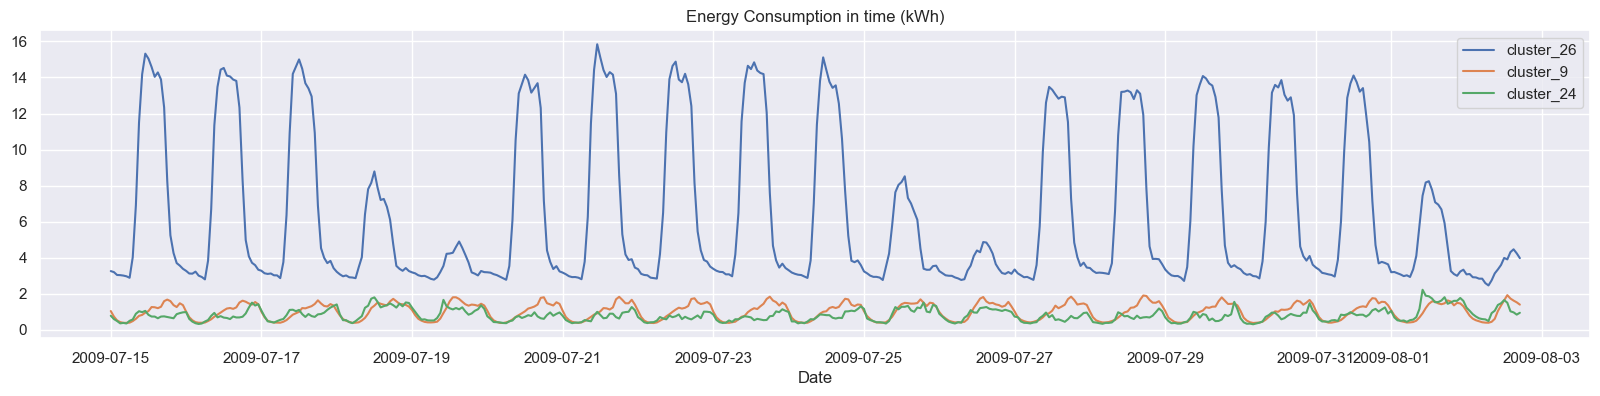

In [11]:
series = df[0:450]

plt.figure(figsize=(20, 4))
plt.plot(series.index, series['cluster_26'], linestyle='-', label = 'cluster_26')
plt.plot(series.index, series['cluster_9'], linestyle='-', label = 'cluster_9')
plt.plot(series.index, series['cluster_24'], linestyle='-', label = 'cluster_24')
plt.title("Energy Consumption in time (kWh)")
plt.xlabel("Date")
plt.legend(loc='upper right');


We observe a marked seasonality in cluster 26 and cluster 9, while cluster 24 has peaks but is much noisier. There do not appear to be any trends in the three series.

We visualize the statistics of the series

In [12]:
df.describe()

,cluster_26,cluster_9,cluster_24
count,12838.000000,12838.000000,12838.000000
mean,7.210478,1.173191,0.707295
std,4.999290,0.627206,0.390985
min,2.457593,0.330619,0.135774
25%,3.548634,0.588801,0.410935
50%,4.470976,1.091933,0.592541
75%,10.925528,1.606156,0.921184
max,23.273883,3.571644,2.711129


We observe that cluster_26 has a higher range of values compared to the other two

### Handling missing values

In [13]:
df.isna().sum()

cluster_26    0
cluster_9     0
cluster_24    0
dtype: int64

There are no missing values in the values of the three series.  
We now check whether there are missing values within the date range, i.e. we check whether, for each day in the series, data is actually recorded for all 24 hours.

In [14]:
counts = df.resample("d").size()
counts[counts != 24]

row ID
2010-03-28    23
2010-03-29    23
Freq: D, dtype: int64

Two dates show 23 recordings instead of 24. We look at these dates in detail.

In [15]:
df.loc["2010-03-28 00:00:00":"2010-03-30 00:00:00"].index

DatetimeIndex(['2010-03-28 00:00:00', '2010-03-28 02:00:00',
               '2010-03-28 03:00:00', '2010-03-28 04:00:00',
               '2010-03-28 05:00:00', '2010-03-28 06:00:00',
               '2010-03-28 07:00:00', '2010-03-28 08:00:00',
               '2010-03-28 09:00:00', '2010-03-28 10:00:00',
               '2010-03-28 11:00:00', '2010-03-28 12:00:00',
               '2010-03-28 13:00:00', '2010-03-28 14:00:00',
               '2010-03-28 15:00:00', '2010-03-28 16:00:00',
               '2010-03-28 17:00:00', '2010-03-28 18:00:00',
               '2010-03-28 19:00:00', '2010-03-28 20:00:00',
               '2010-03-28 21:00:00', '2010-03-28 22:00:00',
               '2010-03-28 23:00:00', '2010-03-29 00:00:00',
               '2010-03-29 02:00:00', '2010-03-29 03:00:00',
               '2010-03-29 04:00:00', '2010-03-29 05:00:00',
               '2010-03-29 06:00:00', '2010-03-29 07:00:00',
               '2010-03-29 08:00:00', '2010-03-29 09:00:00',
               '2010-03-

We notice that the recordings for 01:00:00 are missing for both March 28 and March 29, 2010.  
Since forecasting models require a continuous series with a fixed frequency, we assign the series an hourly frequency, introducing NaNs at those two points.

In [16]:
df = df.asfreq("h")
df.isna().sum()

cluster_26    2
cluster_9     2
cluster_24    2
dtype: int64

As expected, there are now two rows of missing values for the three series.

We visualize them in the following chart

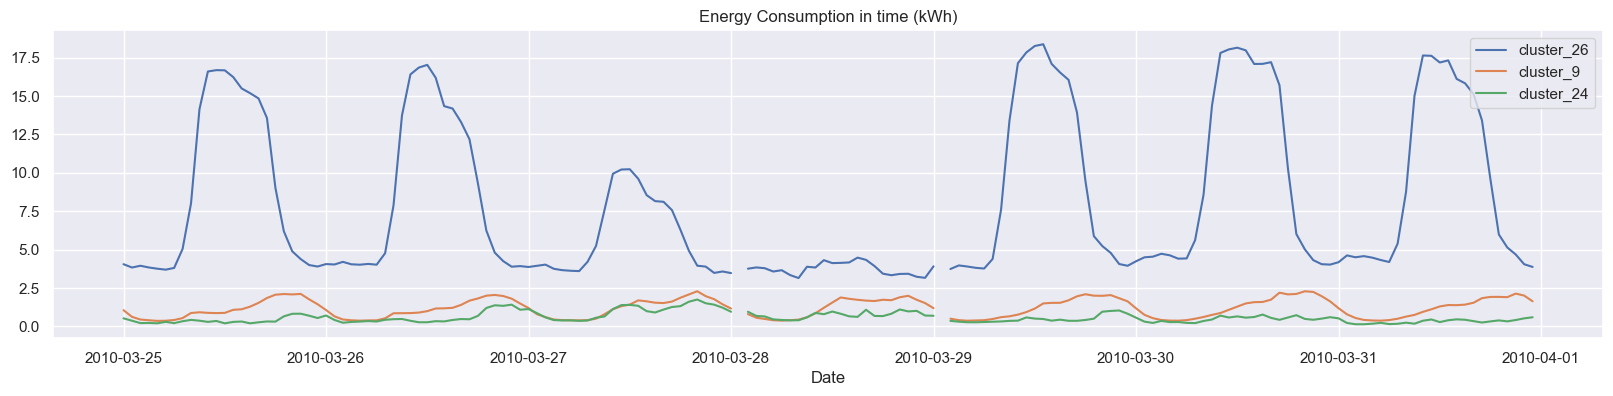

In [17]:
to_viz = df.loc["2010-03-25":"2010-03-31"]

plt.figure(figsize=(20, 4))
plt.plot(to_viz.index, to_viz['cluster_26'], linestyle='-', label = 'cluster_26')
plt.plot(to_viz.index, to_viz['cluster_9'], linestyle='-', label = 'cluster_9')
plt.plot(to_viz.index, to_viz['cluster_24'], linestyle='-', label = 'cluster_24')
plt.title("Energy Consumption in time (kWh)")
plt.xlabel("Date")
plt.legend(loc='upper right');

We impute the NaNs with the previous value using the ffill() method and then visualize the result

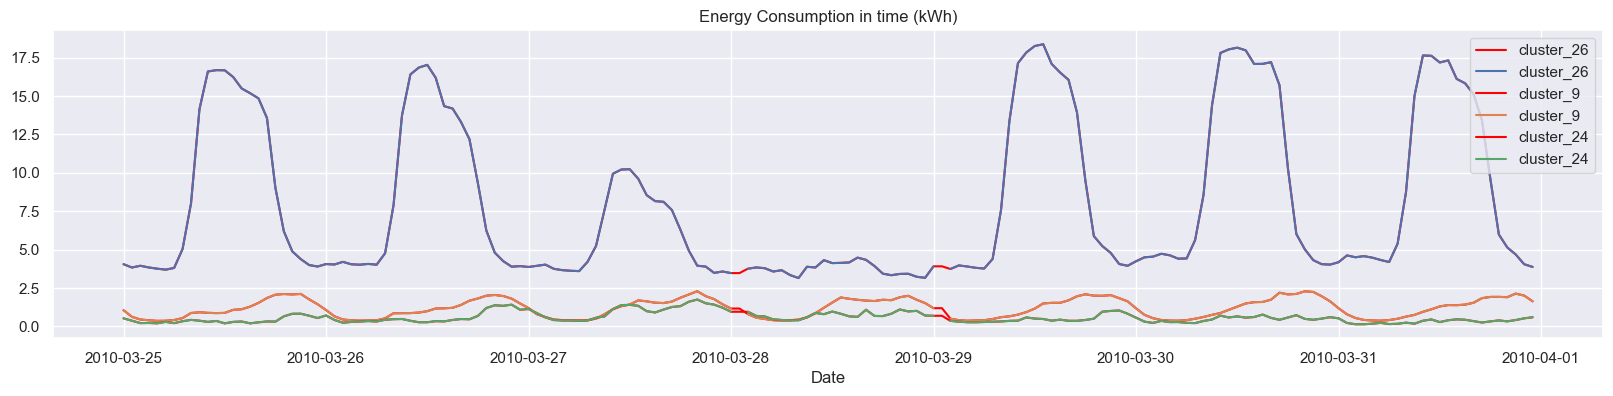

In [18]:
filled = df.ffill()

to_viz_filled = filled.loc["2010-03-25":"2010-03-31"]

plt.figure(figsize=(20, 4))
plt.plot(to_viz_filled.index, to_viz_filled['cluster_26'], linestyle='-', label = 'cluster_26', color='red')
plt.plot(to_viz.index, to_viz['cluster_26'], linestyle='-', label = 'cluster_26')
plt.plot(to_viz_filled.index, to_viz_filled['cluster_9'], linestyle='-', label = 'cluster_9', color='red')
plt.plot(to_viz.index, to_viz['cluster_9'], linestyle='-', label = 'cluster_9')
plt.plot(to_viz_filled.index, to_viz_filled['cluster_24'], linestyle='-', label = 'cluster_24', color='red')
plt.plot(to_viz.index, to_viz['cluster_24'], linestyle='-', label = 'cluster_24')
plt.title("Energy Consumption in time (kWh)")
plt.xlabel("Date")
plt.legend(loc='upper right');

The replacement is consistent with the trend of the series, so we apply it to the dataset.

In [19]:
df = df.ffill()
df.isna().sum()

cluster_26    0
cluster_9     0
cluster_24    0
dtype: int64

### Handling outliers

We consider as outliers those values with an absolute z-score greater than 3.  
We replace the values with the moving average of the previous 5 values

In [20]:
z_26 = np.abs(zscore(df['cluster_26']))
z_9 = np.abs(zscore(df['cluster_9']))
z_24 = np.abs(zscore(df['cluster_24']))
outliers_26 = (z_26>3)
outliers_9 = (z_9>3)
outliers_24 = (z_24>3)

df_cleaned = df.copy()
df_cleaned.loc[outliers_26, 'cluster_26'] = df_cleaned['cluster_26'].rolling(window=5).mean()[outliers_26].astype('float32')
df_cleaned.loc[outliers_9, 'cluster_9'] = df_cleaned['cluster_9'].rolling(window=5).mean()[outliers_9].astype('float32')
df_cleaned.loc[outliers_24, 'cluster_24'] = df_cleaned['cluster_24'].rolling(window=5).mean()[outliers_24].astype('float32')

In [21]:
print(f'The cluster_26 series had {outliers_26.sum()} outliers')
print(f'The cluster_9 series had {outliers_9.sum()} outliers')
print(f'The cluster_24 series had {outliers_24.sum()} outliers')

The cluster_26 series had 7 outliers
The cluster_9 series had 25 outliers
The cluster_24 series had 141 outliers


We visualize the series again over a narrower range, highlighting any outliers that were removed

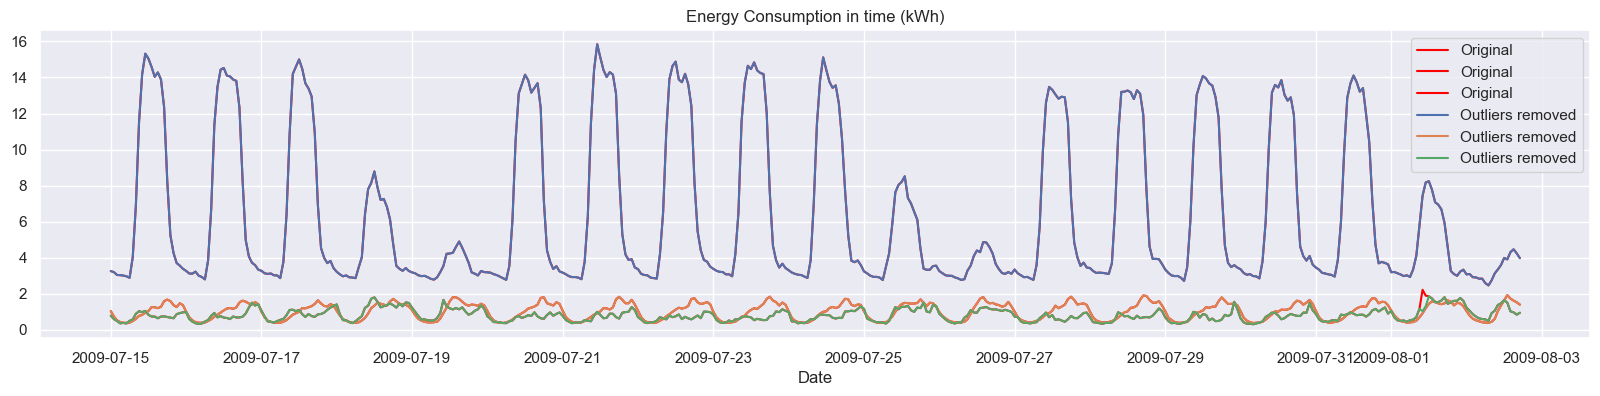

In [ ]:
plt.figure(figsize=(20,4))
plt.plot(df[0:450].index, df[0:450], color="red", label="Original")
plt.plot(df_cleaned[0:450].index, df_cleaned[0:450], label="Outliers removed")
plt.title("Energy Consumption in time (kWh)")
plt.xlabel("Date")
plt.legend();

### Moving averages

We compute the 24h and 168h moving averages to highlight the presence of daily and weekly seasonality

In [ ]:
rolling24 = df_cleaned.rolling(24).mean().bfill().rename(columns={'cluster_26': 'rolling24_26', 'cluster_9': 'rolling24_9', 'cluster_24': 'rolling24_24'})
rolling168 = df_cleaned.rolling(168).mean().bfill().rename(columns={'cluster_26': 'rolling168_26', 'cluster_9': 'rolling168_9', 'cluster_24': 'rolling168_24'})

In [ ]:
df_cleaned = pd.concat((df_cleaned, rolling24, rolling168), axis=1)
df_cleaned.head()

,cluster_26,cluster_9,cluster_24,rolling24_26,rolling24_9,rolling24_24,rolling168_26,rolling168_9,rolling168_24
row ID,,,,,,,,,
2009-07-15 00:00:00,3.254085,1.037702,0.777450,7.743524,0.991931,0.712427,6.589573,1.013808,0.830092
2009-07-15 01:00:00,3.197561,0.730954,0.591275,7.743524,0.991931,0.712427,6.589573,1.013808,0.830092
2009-07-15 02:00:00,3.038390,0.518665,0.483900,7.743524,0.991931,0.712427,6.589573,1.013808,0.830092
2009-07-15 03:00:00,3.029756,0.423768,0.353325,7.743524,0.991931,0.712427,6.589573,1.013808,0.830092
2009-07-15 04:00:00,3.005634,0.382569,0.378625,7.743524,0.991931,0.712427,6.589573,1.013808,0.830092


We graphically observe the three series in their entirety, together with their moving averages

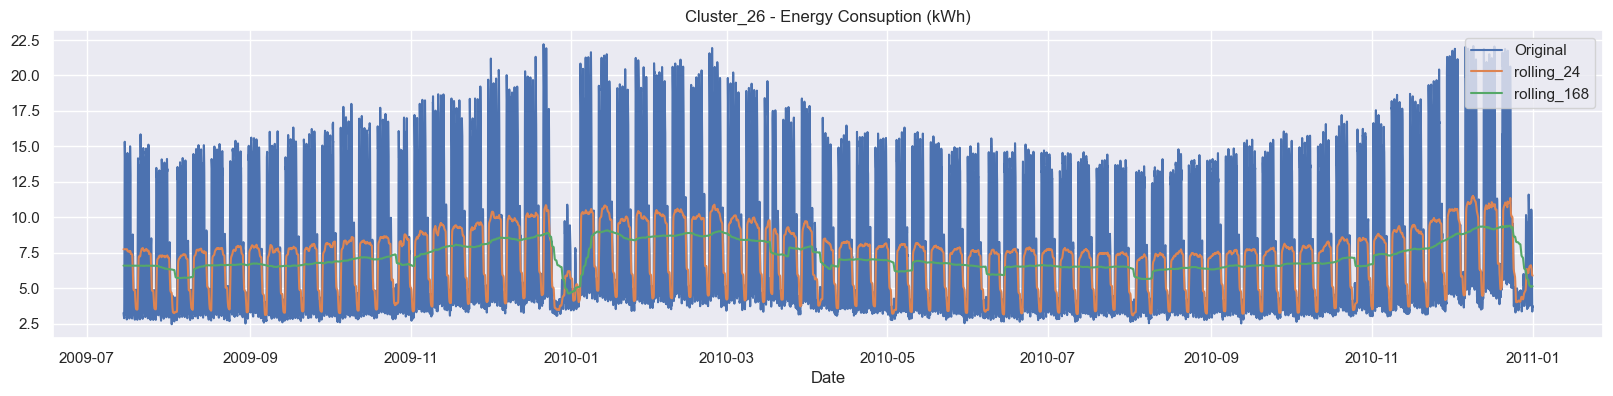

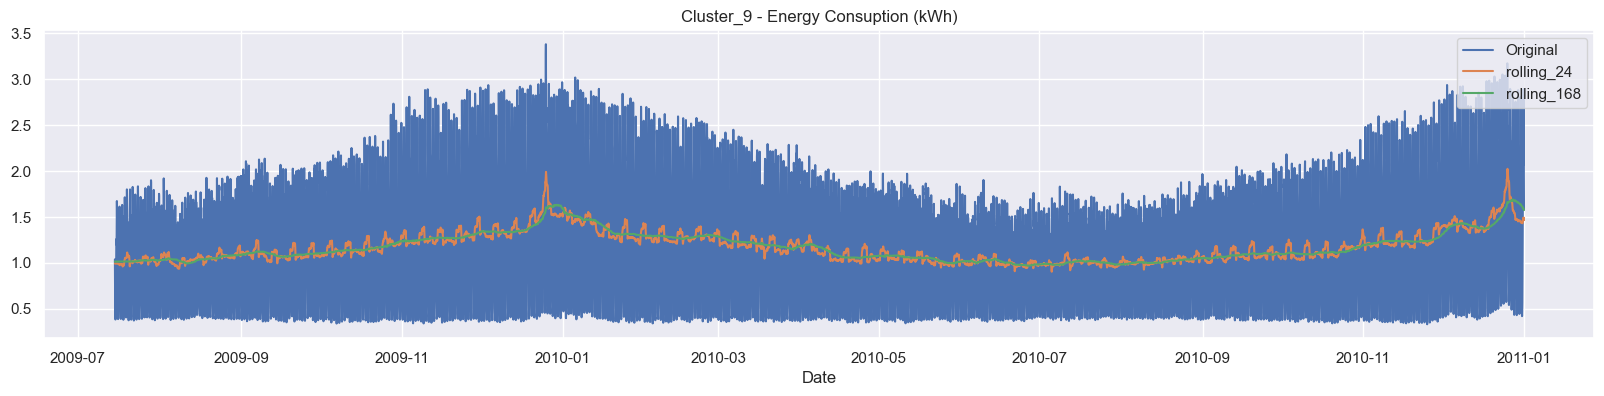

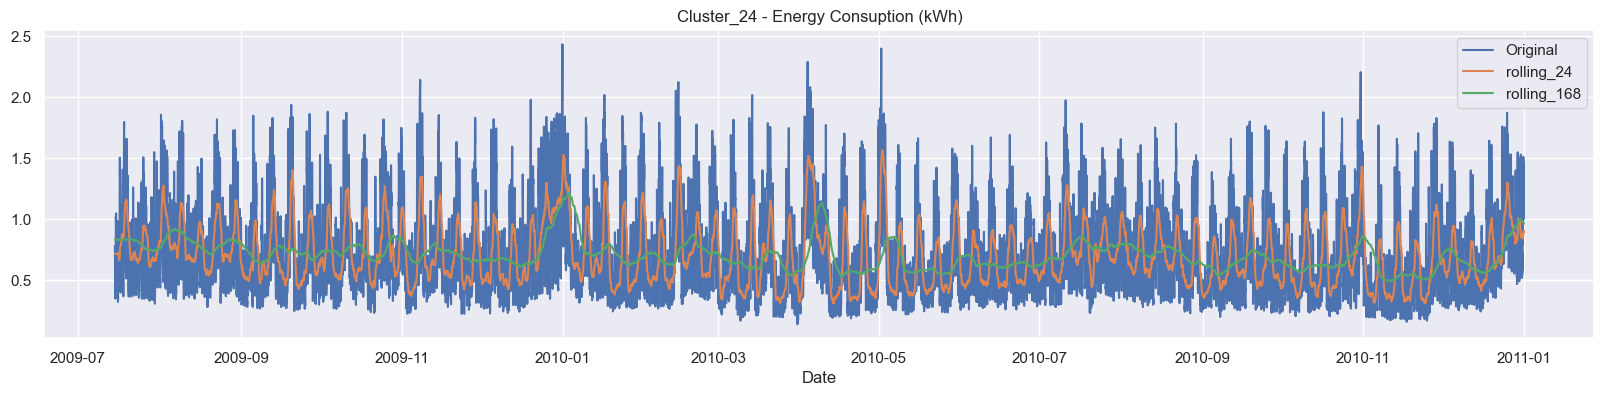

In [ ]:
serie_cleaned = df_cleaned#[0:5000]

plt.figure(figsize=(20, 4))
plt.plot(serie_cleaned.index, serie_cleaned['cluster_26'], label="Original")
plt.plot(serie_cleaned.index, serie_cleaned['rolling24_26'], linestyle='-', label = 'rolling_24')
plt.plot(serie_cleaned.index, serie_cleaned['rolling168_26'], linestyle='-', label = 'rolling_168')
plt.title("Cluster_26 - Energy Consuption (kWh)")
plt.xlabel("Date")
plt.legend(loc='upper right')
plt.show()

plt.figure(figsize=(20, 4))
plt.plot(serie_cleaned.index, serie_cleaned['cluster_9'], label="Original")
plt.plot(serie_cleaned.index, serie_cleaned['rolling24_9'], linestyle='-', label = 'rolling_24')
plt.plot(serie_cleaned.index, serie_cleaned['rolling168_9'], linestyle='-', label = 'rolling_168')
plt.title("Cluster_9 - Energy Consuption (kWh)")
plt.xlabel("Date")
plt.legend(loc='upper right')
plt.show()

plt.figure(figsize=(20, 4))
plt.plot(serie_cleaned.index, serie_cleaned['cluster_24'], label="Original")
plt.plot(serie_cleaned.index, serie_cleaned['rolling24_24'], linestyle='-', label = 'rolling_24')
plt.plot(serie_cleaned.index, serie_cleaned['rolling168_24'], linestyle='-', label = 'rolling_168')
plt.title("Cluster_24 - Energy Consuption (kWh)")
plt.xlabel("Date")
plt.legend(loc='upper right');

Cluster 26: we observe a marked daily and weekly seasonality. We also observe a drop in values in January, both in 2010 and 2011.  
Cluster 9: a daily seasonality is also observed here, while weekly seasonality seems to be absent.  
Cluster 24: at 168 we observe very irregular peaks, while at 24 the peaks are somewhat more regular but variable in intensity and with a certain degree of noise. We cannot say with certainty that there is seasonality.

All the series appear stationary in mean and variance from the charts, with no presence of a trend.
We perform the Dickey-Fuller test to verify this quantitatively.

In [22]:
print("Dickey-Fuller Test - cluster_26\n")
DickeyFuller(df_cleaned['cluster_26'])
print('--------------------------------')
print("\nDickey-Fuller Test - cluster_9")
DickeyFuller(df_cleaned['cluster_9'])
print('--------------------------------')
print("\nDickey-Fuller Test - cluster_24")
DickeyFuller(df_cleaned['cluster_24'])

Dickey-Fuller Test - cluster_26

ADF Statistic -14.407382577724272
p-value 8.313791200078977e-27
-> Stationary series

--------------------------------

Dickey-Fuller Test - cluster_9
ADF Statistic -4.420314063312755
p-value 0.00027320174042838835
-> Stationary series

--------------------------------

Dickey-Fuller Test - cluster_24
ADF Statistic -18.00642601724238
p-value 2.7235620004714133e-30
-> Stationary series



According to the Dickey-Fuller test, all three series are stationary; however, there are clear seasonalities that will need to be addressed.

## Train-test split

We split the series into train and test sequentially, in order to subsequently train forecasting models.

In [ ]:
X_26 = df_cleaned['cluster_26']
X_9 = df_cleaned['cluster_9']
X_24 = df_cleaned['cluster_24']

In [ ]:
train_26, test_26 = splitting(X_26, train_size=0.8)
train_9, test_9 = splitting(X_9, train_size=0.8)
train_24, test_24 = splitting(X_24, train_size=0.8)

## ACF e PACF plots

We now look at the ACF and PACF plots to determine the values to implement in the models and apply any differencing needed to remove seasonality.

#### Cluster_26 series

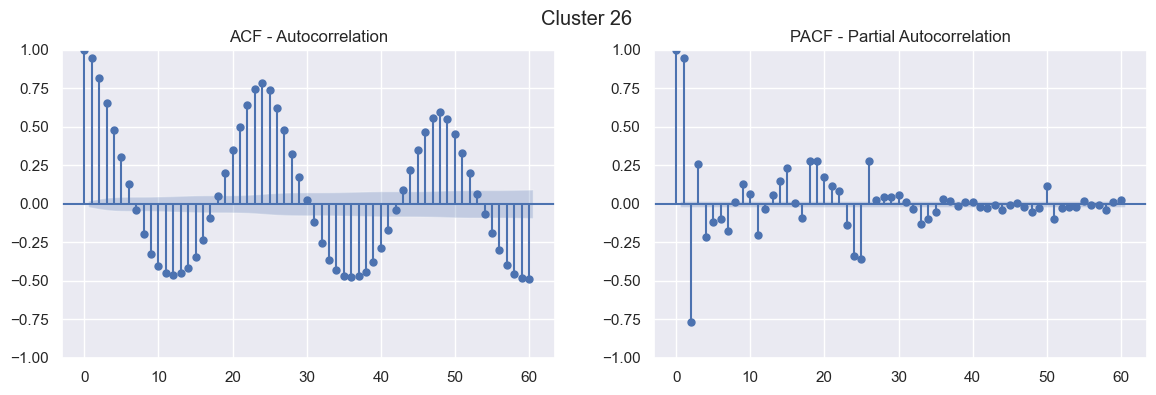

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,4))
plot_acf(train_26, ax=axes[0], lags=60)
plot_pacf(train_26, ax=axes[1], lags=60)
axes[0].set_title("ACF - Autocorrelation")
axes[1].set_title("PACF - Partial Autocorrelation")
plt.suptitle('Cluster 26')
plt.show()

We observe the strong seasonal component already seen graphically, so we apply differencing with a period of 24

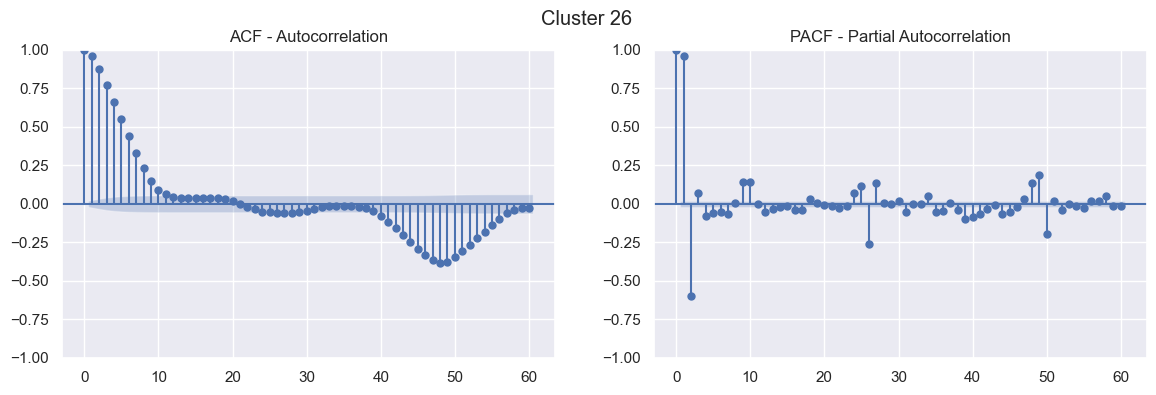

In [ ]:
diff_26 = train_26.diff(24).dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(diff_26, ax=axes[0], lags=60)
plot_pacf(diff_26, ax=axes[1], lags=60)
axes[0].set_title("ACF - Autocorrelation")
axes[1].set_title("PACF - Partial Autocorrelation")
plt.suptitle('Cluster 26');

Now the main seasonal component appears attenuated.  
We observe an ACF that decays gradually toward 0, although at higher lags it tends to take on negative values, particularly around lag 48.  
The PACF shows significant peaks at the first lags and drops noticeably for subsequent values,  
however here too we see residual peaks around lags 24 and 48, indicating the possible presence of a residual cyclical component.  
We therefore hypothesize the use of models with a low-order autoregressive component (1 or 2). We will also try implementing a SARIMA model with a seasonal component of 24 and will attempt to use a P different from 0.

#### Cluster_9 series

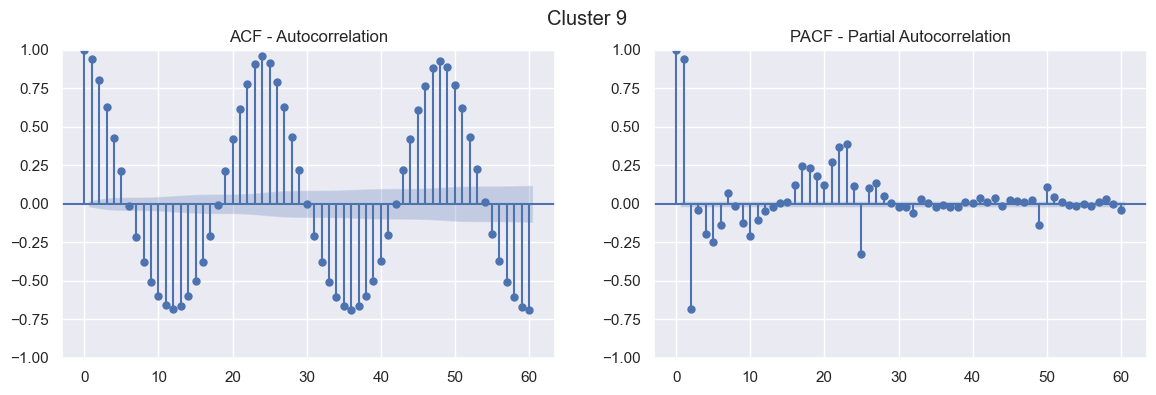

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,4))
plot_acf(train_9, ax=axes[0], lags=60)
plot_pacf(train_9, ax=axes[1], lags=60)
axes[0].set_title("ACF - Autocorrelation")
axes[1].set_title("PACF - Partial Autocorrelation")
plt.suptitle('Cluster 9');

Also in this case we observe a strong seasonal component, so we apply differencing with a period of 24.

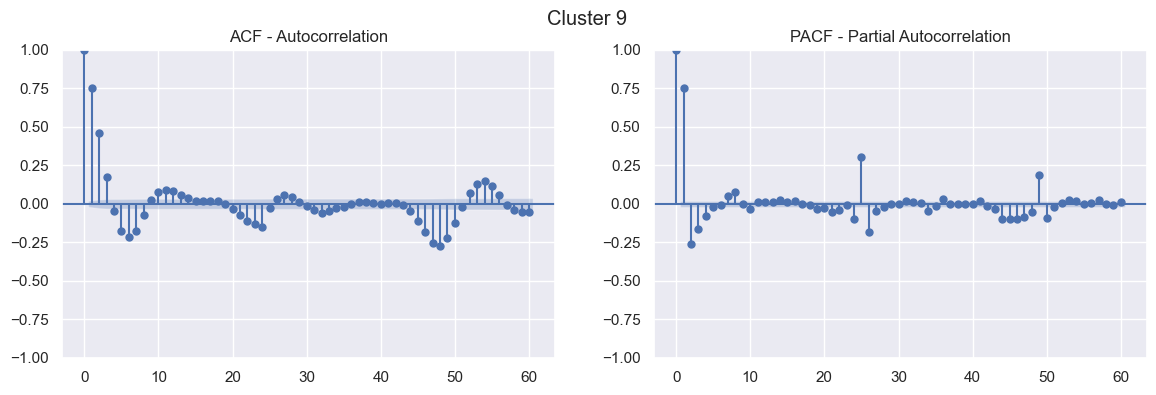

In [ ]:
diff_9 = train_9.diff(24).dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(diff_9, ax=axes[0], lags=60)
plot_pacf(diff_9, ax=axes[1], lags=60)
axes[0].set_title("ACF - Autocorrelation")
axes[1].set_title("PACF - Partial Autocorrelation")
plt.suptitle('Cluster 9');

In this case as well, the seasonal component has been considerably attenuated.  
The ACF shows high values at the first lags and then decays rapidly toward 0, while still retaining some evidence of residual seasonality around lags 24 and 48.  
The PACF shows a high value at lag 1 and then drops sharply. Residual peaks are also noticeable at lags 24 and 48, indicating a possible residual seasonal component.  
In this case, besides an autoregressive component with p equal to 1 or 2, we will also try applying a model with q=1 or 2, given the behavior of the ACF.  
We will also try introducing a SARIMA model with seasonality of 24.

#### Cluster_24 series

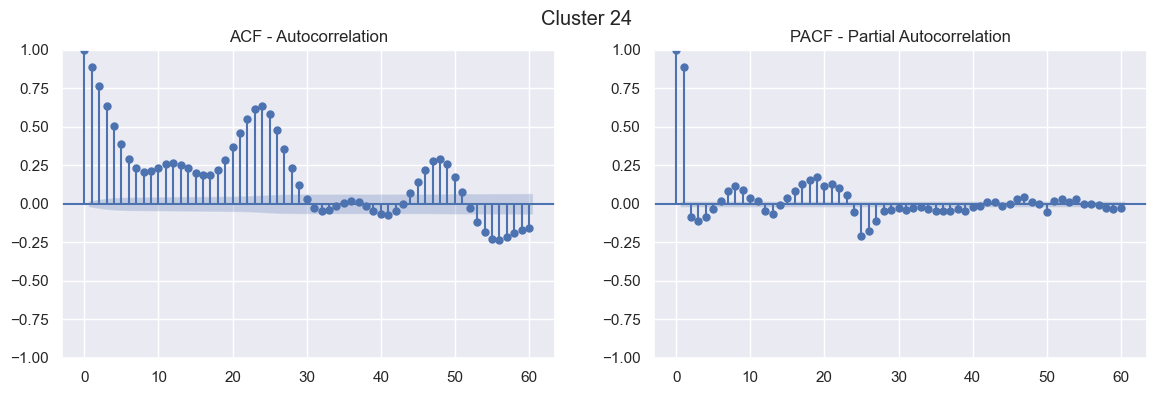

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,4))
plot_acf(train_24, ax=axes[0], lags=60)
plot_pacf(train_24, ax=axes[1], lags=60)
axes[0].set_title("ACF - Autocorrelation")
axes[1].set_title("PACF - Partial Autocorrelation")
plt.suptitle('Cluster 24');

In this case there is no marked seasonality, as was already evident from the raw series chart. However, the ACF plot shows a possible periodic structure, again with period 24. We therefore try applying differencing with period 24 also in this case.

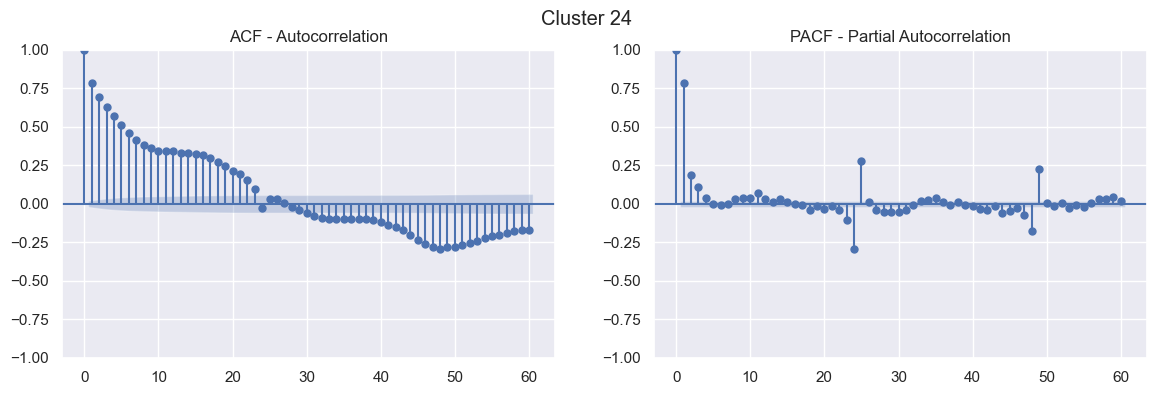

In [ ]:
diff_24 = train_24.diff(24).dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(diff_24, ax=axes[0], lags=60)
plot_pacf(diff_24, ax=axes[1], lags=60)
axes[0].set_title("ACF - Autocorrelation")
axes[1].set_title("PACF - Partial Autocorrelation")
plt.suptitle('Cluster 24');

After differencing, we observe an attenuation of the hypothesized periodic component. However, the PACF still shows a few peaks at higher values, which could indicate the presence of an unaccounted-for seasonal component.  
Also in this case, we still observe an ACF with a slow, gradual decay and a PACF with a sharper drop after the first lag, again suggesting a low-order autoregressive component.

## Classical models

### Cluster_26 series

We train an AR(1) baseline model, to do so we use the ARIMA class, setting the d and q values to 0.

In [ ]:
ar_model_26 = ARIMA(train_26, order=(1,0,0))
ar_result_26 = ar_model_26.fit()
ar_result_26.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:             cluster_26   No. Observations:                10272
Model:                 ARIMA(1, 0, 0)   Log Likelihood              -19253.040
Date:                Mon, 07 Sep 2026   AIC                          38512.079
Time:                        09:40:01   BIC                          38533.791
Sample:                    07-15-2009   HQIC                         38519.418
                         - 09-15-2010                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.1280      0.416     17.145      0.000       6.313       7.943
ar.L1          0.9473      0.005    204.235      0.000       0.938       0.956
sigma2         2.4856      0.022    114.184      0.000       2.443       2.528
===================================================================================
Ljung-Box (L1) (Q):                5442.77   Jarque-Bera (JB):             13694.43
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.76   Skew:                             1.14
Prob(H) (two-sided):                  0.00   Kurtosis:                         8.18
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

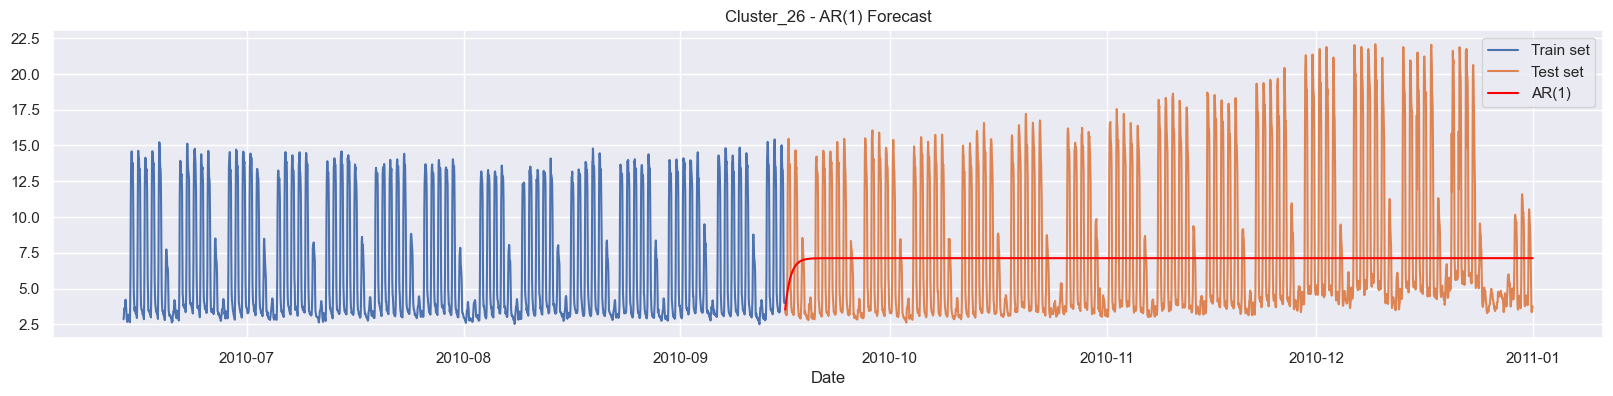

In [ ]:
ar_forecast_26 = ar_result_26.get_forecast(steps=int(len(test_26)))
ar_26_pred_mean = ar_forecast_26.predicted_mean

start_serie = 8000
end_serie = 10270
plt.figure(figsize=(20, 4))
plt.plot(train_26[start_serie:end_serie], label="Train set")
plt.plot(test_26, label="Test set")
plt.plot(ar_26_pred_mean.index, ar_26_pred_mean, label="AR(1)", color="red")
plt.title("Cluster_26 - AR(1) Forecast")
plt.xlabel("Date")
plt.legend();

Given the ACF and PACF analysis, we also implement an ARIMA model with p=2

In [ ]:
arima_model_26 = ARIMA(train_26, order=(2,0,0))
arima_result_26 = arima_model_26.fit()
arima_result_26.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:             cluster_26   No. Observations:                10272
Model:                 ARIMA(2, 0, 0)   Log Likelihood              -14670.071
Date:                Mon, 07 Sep 2026   AIC                          29348.141
Time:                        09:40:03   BIC                          29377.090
Sample:                    07-15-2009   HQIC                         29357.927
                         - 09-15-2010                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.1281      0.146     48.724      0.000       6.841       7.415
ar.L1          1.6751      0.005    316.087      0.000       1.665       1.685
ar.L2         -0.7683      0.005   -146.274      0.000      -0.779      -0.758
sigma2         1.0182      0.012     87.282      0.000       0.995       1.041
===================================================================================
Ljung-Box (L1) (Q):                 421.97   Jarque-Bera (JB):             11415.74
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.81   Skew:                             1.02
Prob(H) (two-sided):                  0.00   Kurtosis:                         7.75
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

We observe that all parameters are significant and that the AIC and BIC have decreased compared to the model with p=1, indicating a better fit.

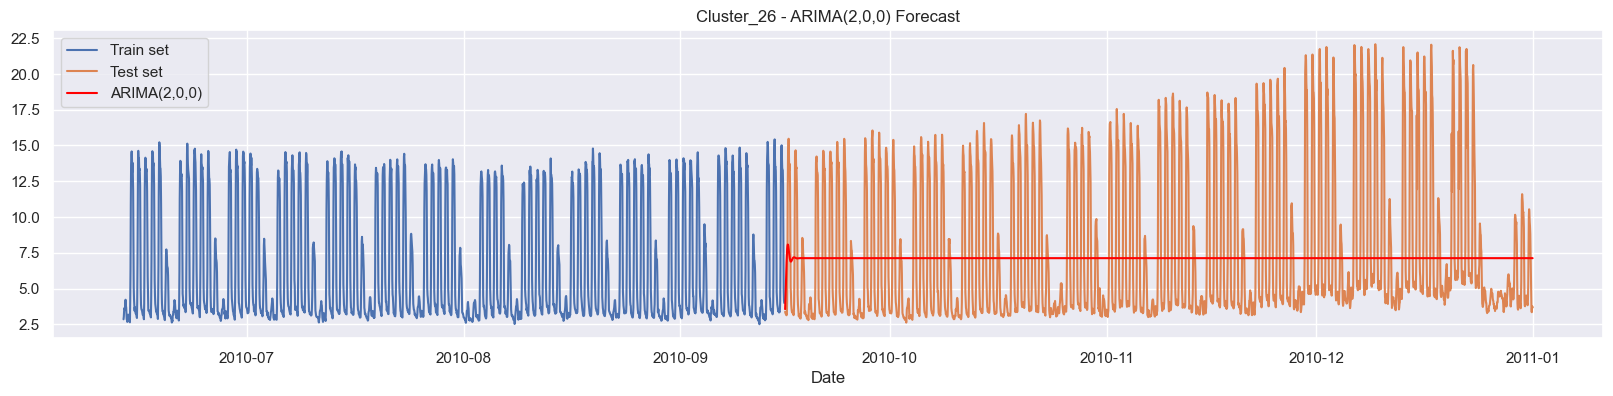

In [ ]:
arima_forecast_26 = arima_result_26.get_forecast(steps=int(len(test_26)))
arima_26_pred_mean = arima_forecast_26.predicted_mean
start_serie = 8000
end_serie = 10270
plt.figure(figsize=(20, 4))
plt.plot(train_26[start_serie:end_serie], label="Train set")
plt.plot(test_26, label="Test set")
plt.plot(arima_26_pred_mean.index, arima_26_pred_mean, label="ARIMA(2,0,0)", color="red")
plt.title("Cluster_26 - ARIMA(2,0,0) Forecast")
plt.xlabel("Date")
plt.legend();

We observe from the chart that the model identifies the direction of the trend and the average value of the series, but does not capture the seasonalities present.  
We now implement a SARIMA model with seasonality of 24

In [ ]:
sarima_model_26 = SARIMAX(train_26, order=(2,0,0), seasonal_order=(1,1,0,24))
sarima_result_26 = sarima_model_26.fit()
sarima_result_26.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                         cluster_26   No. Observations:                10272
Model:             SARIMAX(2, 0, 0)x(1, 1, 0, 24)   Log Likelihood              -10885.232
Date:                            Mon, 07 Sep 2026   AIC                          21778.465
Time:                                    09:40:22   BIC                          21807.404
Sample:                                07-15-2009   HQIC                         21788.249
                                     - 09-15-2010                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.5627      0.005    304.454      0.000       1.553       1.573
ar.L2         -0.6252      0.005   -115.767      0.000      -0.636      -0.615
ar.S.L24      -0.2516      0.006    -38.756      0.000      -0.264      -0.239
sigma2         0.4897      0.004    128.669      0.000       0.482       0.497
===================================================================================
Ljung-Box (L1) (Q):                  44.00   Jarque-Bera (JB):             37850.64
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.88   Skew:                             0.36
Prob(H) (two-sided):                  0.00   Kurtosis:                        12.39
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

All parameters result to be significant and the AIC and BIC decrease compared to the baseline.  
We now look at the forecast graphically.

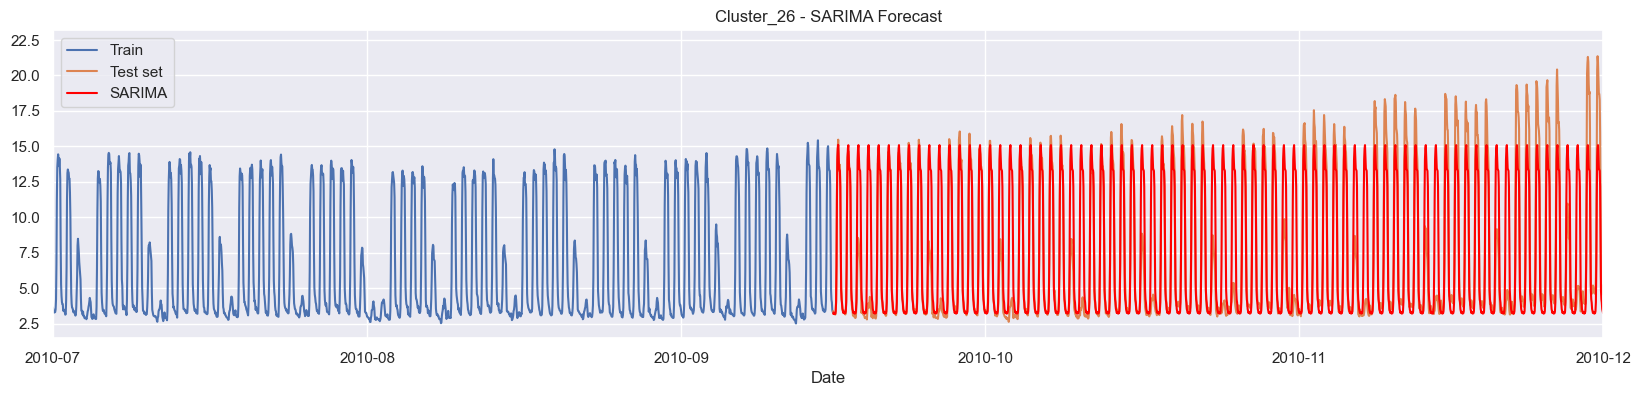

In [ ]:
sarima_forecast_26 = sarima_result_26.get_forecast(steps=int(len(test_26)))
sarima_26_pred_mean = sarima_forecast_26.predicted_mean
plt.figure(figsize=(20, 4))
plt.plot(train_26, label="Train")
plt.plot(test_26, label="Test set")
plt.plot(sarima_26_pred_mean.index, sarima_26_pred_mean, label="SARIMA", color="red")
plt.title("Cluster_26 - SARIMA Forecast")
plt.xlim(pd.Timestamp('2010-07'), pd.Timestamp('2010-12'))
plt.xlabel("Date")
plt.legend();

We observe that, compared to the ARIMA model, this model is also able to predict the 24-hour seasonality. However, it does not capture the weekly seasonality.

##### Forecast evaluation

We compare the models built using their forecasting error on the test set.

In [ ]:
metrics_results_func(test_26, [ar_26_pred_mean, arima_26_pred_mean, sarima_26_pred_mean], models=['AR(1)', 'ARIMA', 'SARIMA'], metrics=['RMSE', 'MAE', 'MAPE'])

,Metric,AR(1),ARIMA,SARIMA
0,RMSE,5.2588,5.2512,3.3408
1,MAE,4.2708,4.2721,2.0812
2,MAPE,0.6651,0.6677,0.3363


For all three metrics, we can observe that the ARIMA model with p=2 adds practically nothing compared to the baseline; in fact, the MAE and MAPE increase slightly. With the SARIMA model, on the other hand, the error decreases markedly, confirming that this is a better model than ARIMA since it accounts for the 24-hour seasonality.

### Cluster_9 series

AR(1) baseline

In [ ]:
ar_model_9 = ARIMA(train_9, order=(1,0,0))
ar_result_9 = ar_model_9.fit()
ar_result_9.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:              cluster_9   No. Observations:                10272
Model:                 ARIMA(1, 0, 0)   Log Likelihood                1651.490
Date:                Mon, 07 Sep 2026   AIC                          -3296.979
Time:                        09:40:24   BIC                          -3275.268
Sample:                    07-15-2009   HQIC                         -3289.640
                         - 09-15-2010                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.1494      0.038     30.498      0.000       1.076       1.223
ar.L1          0.9401      0.004    238.475      0.000       0.932       0.948
sigma2         0.0424      0.001     84.535      0.000       0.041       0.043
===================================================================================
Ljung-Box (L1) (Q):                4262.28   Jarque-Bera (JB):               463.40
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.60   Skew:                             0.24
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.92
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

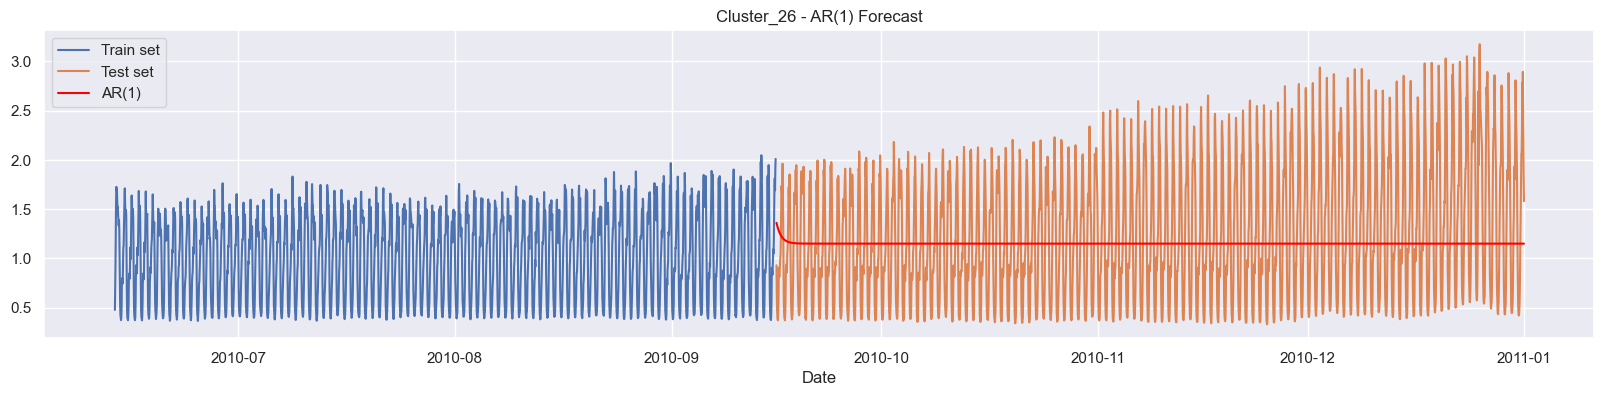

In [ ]:
ar_forecast_9 = ar_result_9.get_forecast(steps=int(len(test_9)))
ar_9_pred_mean = ar_forecast_9.predicted_mean

start_serie = 8000
end_serie = 10270
plt.figure(figsize=(20, 4))
plt.plot(train_9[start_serie:end_serie], label="Train set")
plt.plot(test_9, label="Test set")
plt.plot(ar_9_pred_mean.index, ar_9_pred_mean, label="AR(1)", color="red")
plt.title("Cluster_26 - AR(1) Forecast")
plt.xlabel("Date")
plt.legend();

In this case, given the behavior of the ACF, in addition to p=1, we try introducing q=1 and then q=2 into the ARIMA model

In [ ]:
arima_model_9 = ARIMA(train_9, order=(2,0,1))
arima_result_9= arima_model_9.fit()
arima_result_9.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:              cluster_9   No. Observations:                10272
Model:                 ARIMA(2, 0, 1)   Log Likelihood                4930.519
Date:                Mon, 07 Sep 2026   AIC                          -9851.038
Time:                        09:40:29   BIC                          -9814.852
Sample:                    07-15-2009   HQIC                         -9838.805
                         - 09-15-2010                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.1494      0.016     72.847      0.000       1.118       1.180
ar.L1          1.7032      0.009    189.068      0.000       1.686       1.721
ar.L2         -0.7960      0.009    -90.813      0.000      -0.813      -0.779
ma.L1         -0.2409      0.011    -22.204      0.000      -0.262      -0.220
sigma2         0.0224      0.000    112.756      0.000       0.022       0.023
===================================================================================
Ljung-Box (L1) (Q):                  31.49   Jarque-Bera (JB):              5907.09
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.65   Skew:                             0.45
Prob(H) (two-sided):                  0.00   Kurtosis:                         6.60
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
arima_model_9 = ARIMA(train_9, order=(2,0,2))
arima_result_9= arima_model_9.fit()
arima_result_9.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:              cluster_9   No. Observations:                10272
Model:                 ARIMA(2, 0, 2)   Log Likelihood                5416.925
Date:                Mon, 07 Sep 2026   AIC                         -10821.851
Time:                        09:40:39   BIC                         -10778.428
Sample:                    07-15-2009   HQIC                        -10807.172
                         - 09-15-2010                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.1495      0.008    142.234      0.000       1.134       1.165
ar.L1          1.8517      0.006    290.820      0.000       1.839       1.864
ar.L2         -0.9198      0.006   -155.189      0.000      -0.931      -0.908
ma.L1         -0.3951      0.009    -44.874      0.000      -0.412      -0.378
ma.L2         -0.3017      0.007    -42.720      0.000      -0.316      -0.288
sigma2         0.0204      0.000    113.633      0.000       0.020       0.021
===================================================================================
Ljung-Box (L1) (Q):                   0.47   Jarque-Bera (JB):              9696.29
Prob(Q):                              0.49   Prob(JB):                         0.00
Heteroskedasticity (H):               0.68   Skew:                             0.65
Prob(H) (two-sided):                  0.00   Kurtosis:                         7.58
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

The model with the lowest AIC and BIC turns out to be the one with p=2 and q=2

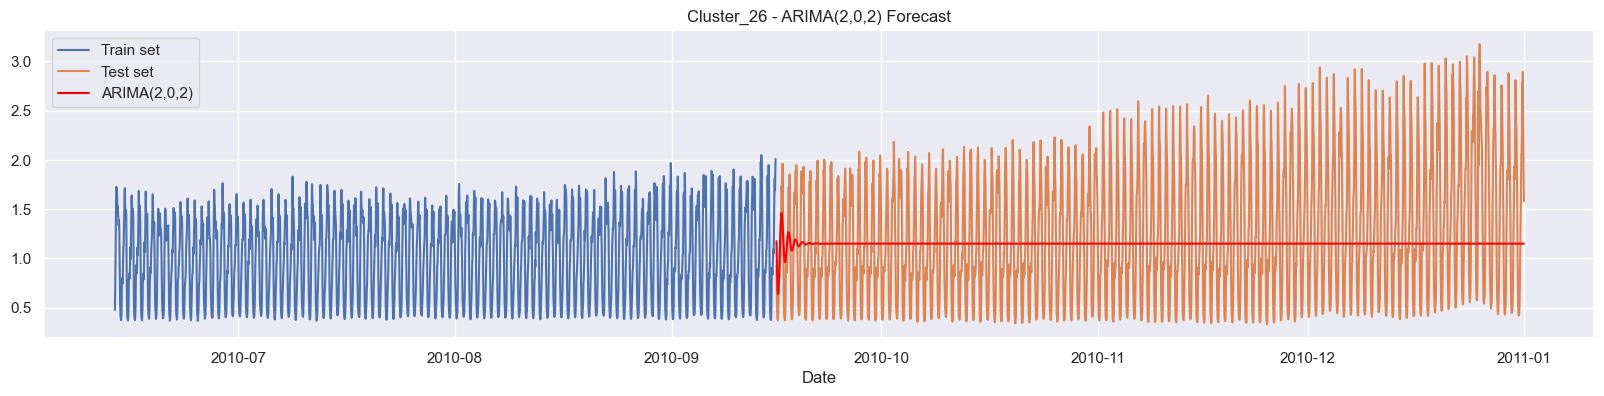

In [ ]:
arima_forecast_9 = arima_result_9.get_forecast(steps=int(len(test_9)))
arima_9_pred_mean = arima_forecast_9.predicted_mean

start_serie = 8000
end_serie = 10270
plt.figure(figsize=(20, 4))
plt.plot(train_9[start_serie:end_serie], label="Train set")
plt.plot(test_9, label="Test set")
plt.plot(arima_9_pred_mean.index, arima_9_pred_mean, label="ARIMA(2,0,2)", color="red")
plt.title("Cluster_26 - ARIMA(2,0,2) Forecast")
plt.xlabel("Date")
plt.legend();

From the chart we see that, also in this case, the seasonality is not captured

We implement the SARIMA model with seasonality of 24

In [ ]:
sarima_model_9 = SARIMAX(train_9, order=(2,0,2), seasonal_order=(1,1,1,24))
sarima_result_9 = sarima_model_9.fit()
sarima_result_9.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                            cluster_9   No. Observations:                10272
Model:             SARIMAX(2, 0, 2)x(1, 1, [1], 24)   Log Likelihood               10412.170
Date:                              Mon, 07 Sep 2026   AIC                         -20810.340
Time:                                      09:42:17   BIC                         -20759.696
Sample:                                  07-15-2009   HQIC                        -20793.218
                                       - 09-15-2010                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.3890      0.019     74.350      0.000       1.352       1.426
ar.L2         -0.6060      0.012    -50.225      0.000      -0.630      -0.582
ma.L1         -0.4211      0.019    -22.717      0.000      -0.457      -0.385
ma.L2          0.0304      0.011      2.811      0.005       0.009       0.052
ar.S.L24       0.2166      0.007     29.316      0.000       0.202       0.231
ma.S.L24      -0.8867      0.004   -236.075      0.000      -0.894      -0.879
sigma2         0.0077   5.45e-05    140.508      0.000       0.008       0.008
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):             22446.95
Prob(Q):                              0.92   Prob(JB):                         0.00
Heteroskedasticity (H):               0.68   Skew:                             0.29
Prob(H) (two-sided):                  0.00   Kurtosis:                        10.23
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

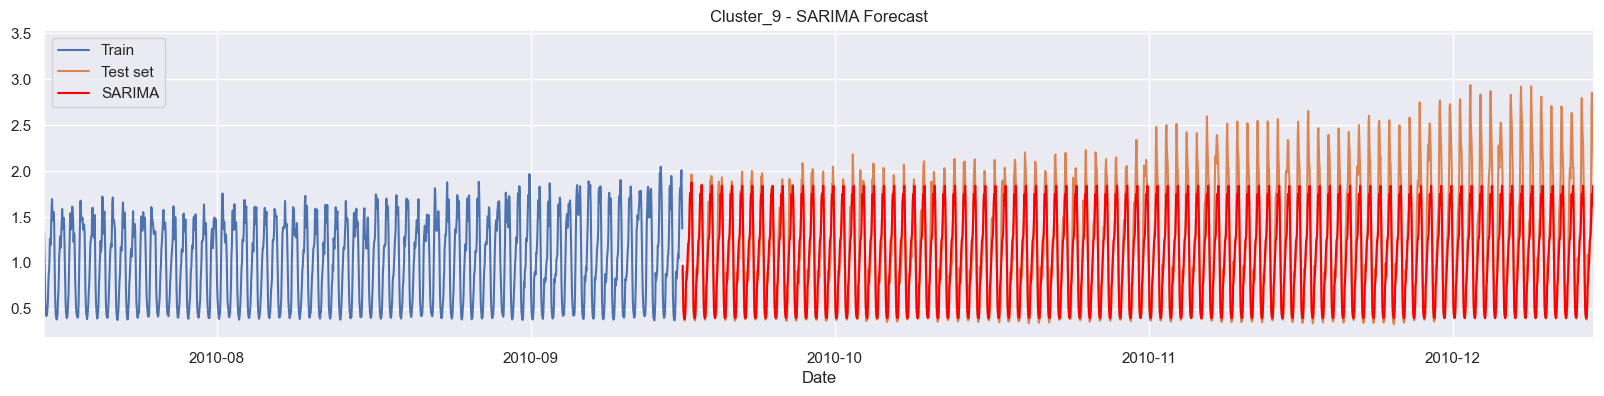

In [ ]:
sarima_forecast_9 = sarima_result_9.get_forecast(steps=int(len(test_9)))
sarima_9_pred_mean = sarima_forecast_9.predicted_mean
plt.figure(figsize=(20, 4))
plt.plot(train_9, label="Train")
plt.plot(test_9, label="Test set")
plt.plot(sarima_9_pred_mean.index, sarima_9_pred_mean, label="SARIMA", color="red")
plt.title("Cluster_9 - SARIMA Forecast")
plt.xlim(pd.Timestamp('2010-07-15'), pd.Timestamp('2010-12-15'))
plt.xlabel("Date")
plt.legend();

In this case, the model captures the seasonality of the series well, with some error on the higher values.

##### Forecast evaluation

In [ ]:
metrics_results_func(test_9, pred_values=[ar_9_pred_mean, arima_9_pred_mean, sarima_9_pred_mean])

,Metric,AR(1),ARIMA,SARIMA
0,RMSE,0.6991,0.6963,0.3657
1,MAE,0.5887,0.5848,0.2369
2,MAPE,0.6553,0.6486,0.1586


Also in this case we can see a marked improvement in performances with the SARIMA model.

### Cluster_24 series

In [ ]:
ar_model_24 = ARIMA(train_24, order=(1,0,0))
ar_result_24 = ar_model_24.fit()
ar_result_24.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:             cluster_24   No. Observations:                10272
Model:                 ARIMA(1, 0, 0)   Log Likelihood                3278.003
Date:                Mon, 07 Sep 2026   AIC                          -6550.005
Time:                        09:42:18   BIC                          -6528.293
Sample:                    07-15-2009   HQIC                         -6542.666
                         - 09-15-2010                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7145      0.019     38.283      0.000       0.678       0.751
ar.L1          0.8862      0.005    192.847      0.000       0.877       0.895
sigma2         0.0309      0.000     94.613      0.000       0.030       0.032
===================================================================================
Ljung-Box (L1) (Q):                  62.45   Jarque-Bera (JB):              2296.85
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.98   Skew:                             0.53
Prob(H) (two-sided):                  0.54   Kurtosis:                         5.06
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
arima_model_24 = ARIMA(train_24, order=(2,0,0))
arima_result_24 = arima_model_24.fit()
arima_result_24.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:             cluster_24   No. Observations:                10272
Model:                 ARIMA(2, 0, 0)   Log Likelihood                3317.909
Date:                Mon, 07 Sep 2026   AIC                          -6627.818
Time:                        09:42:20   BIC                          -6598.869
Sample:                    07-15-2009   HQIC                         -6618.032
                         - 09-15-2010                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7145      0.017     41.590      0.000       0.681       0.748
ar.L1          0.9642      0.009    108.859      0.000       0.947       0.982
ar.L2         -0.0880      0.008    -10.654      0.000      -0.104      -0.072
sigma2         0.0307      0.000     95.245      0.000       0.030       0.031
===================================================================================
Ljung-Box (L1) (Q):                   0.97   Jarque-Bera (JB):              2337.61
Prob(Q):                              0.32   Prob(JB):                         0.00
Heteroskedasticity (H):               0.99   Skew:                             0.51
Prob(H) (two-sided):                  0.77   Kurtosis:                         5.10
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In this case, the reduction in AIC and BIC with p=2 is much less pronounced than for the other two series

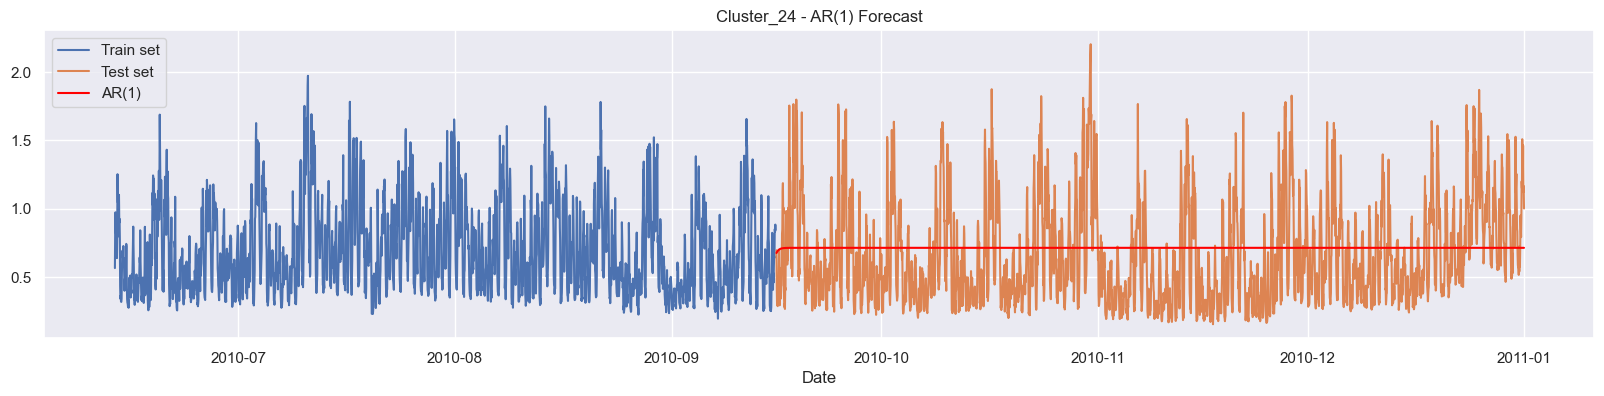

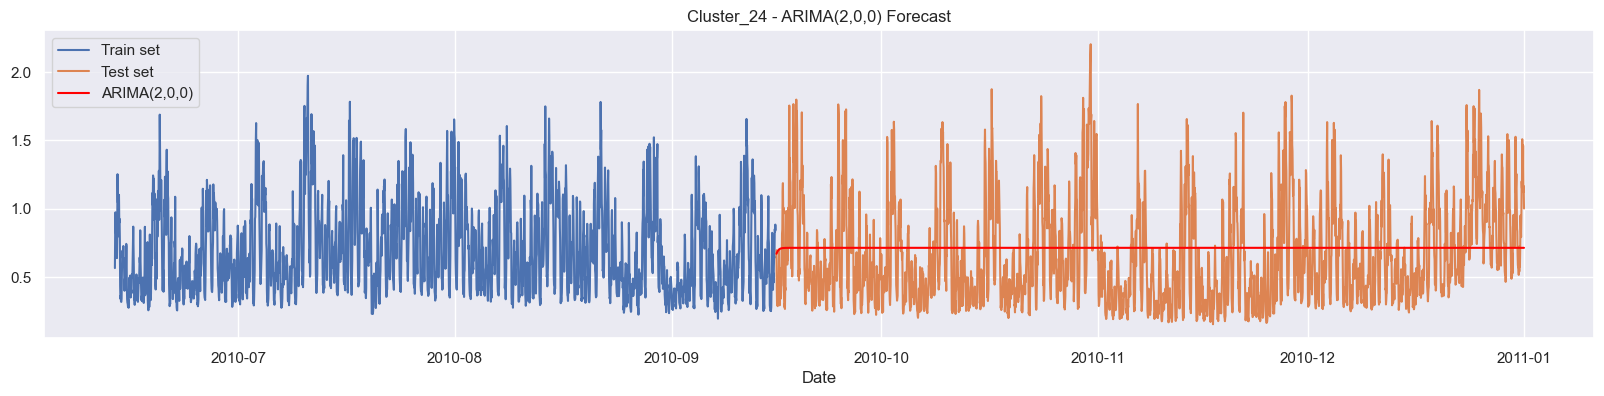

In [ ]:
ar_forecast_24 = ar_result_24.get_forecast(steps=int(len(test_24)))
ar_24_pred_mean = ar_forecast_24.predicted_mean
start_serie = 8000
end_serie = 10270
plt.figure(figsize=(20, 4))
plt.plot(train_24[start_serie:end_serie], label="Train set")
plt.plot(test_24, label="Test set")
plt.plot(ar_24_pred_mean.index, ar_24_pred_mean, label="AR(1)", color="red")
plt.title("Cluster_24 - AR(1) Forecast")
plt.xlabel("Date")
plt.legend();

arima_forecast_24 = arima_result_24.get_forecast(steps=int(len(test_24)))
arima_24_pred_mean = arima_forecast_24.predicted_mean
start_serie = 8000
end_serie = 10270
plt.figure(figsize=(20, 4))
plt.plot(train_24[start_serie:end_serie], label="Train set")
plt.plot(test_24, label="Test set")
plt.plot(arima_24_pred_mean.index, arima_24_pred_mean, label="ARIMA(2,0,0)", color="red")
plt.title("Cluster_24 - ARIMA(2,0,0) Forecast")
plt.xlabel("Date")
plt.legend();

Indeed, even graphically, the difference between the two models is minimal.

We try implementing a SARIMA model also in this case, given the possible presence of seasonality that emerged from the ACF and PACF analysis

In [ ]:
sarima_model_24 = SARIMAX(train_24, order=(2,0,0), seasonal_order=(1,1,1,24))
sarima_result_24 = sarima_model_24.fit()
sarima_result_24.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                           cluster_24   No. Observations:                10272
Model:             SARIMAX(2, 0, 0)x(1, 1, [1], 24)   Log Likelihood                4774.144
Date:                              Mon, 07 Sep 2026   AIC                          -9538.288
Time:                                      09:43:42   BIC                          -9502.114
Sample:                                  07-15-2009   HQIC                         -9526.058
                                       - 09-15-2010                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7175      0.008     92.339      0.000       0.702       0.733
ar.L2          0.1620      0.008     20.205      0.000       0.146       0.178
ar.S.L24       0.1424      0.008     16.750      0.000       0.126       0.159
ma.S.L24      -0.9686      0.003   -380.950      0.000      -0.974      -0.964
sigma2         0.0229      0.000    104.612      0.000       0.022       0.023
===================================================================================
Ljung-Box (L1) (Q):                   1.96   Jarque-Bera (JB):              2939.02
Prob(Q):                              0.16   Prob(JB):                         0.00
Heteroskedasticity (H):               0.98   Skew:                             0.58
Prob(H) (two-sided):                  0.47   Kurtosis:                         5.35
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

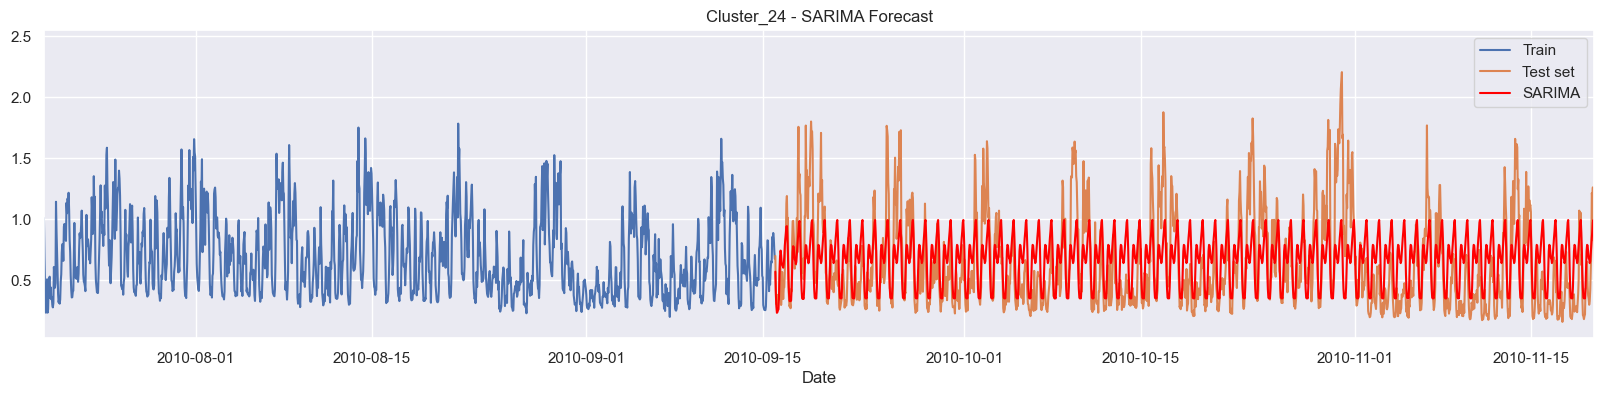

In [ ]:
sarima_forecast_24 = sarima_result_24.get_forecast(steps=int(len(test_24)))
sarima_24_pred_mean = sarima_forecast_24.predicted_mean
plt.figure(figsize=(20, 4))
plt.plot(train_24, label="Train")
plt.plot(test_24, label="Test set")
plt.plot(sarima_24_pred_mean.index, sarima_24_pred_mean, label="SARIMA", color="red")
plt.title("Cluster_24 - SARIMA Forecast")
plt.xlim(pd.Timestamp('2010-07-20'), pd.Timestamp('2010-11-20'))
plt.xlabel("Date")
plt.legend();

In [ ]:
metrics_results_func(test_24, pred_values=[ar_24_pred_mean, arima_24_pred_mean, sarima_24_pred_mean])

,Metric,AR(1),ARIMA,SARIMA
0,RMSE,0.3799,0.3799,0.3142
1,MAE,0.3181,0.3181,0.2439
2,MAPE,0.6870,0.6870,0.4532


Here too, the SARIMA model has better forecasting performance and also has lower AIC and BIC on the train set, managing to capture the variability of the series somewhat better.

## Recurrent models

We train an LSTM neural network.  

To do this, we first prepare the data using a function created specifically to obtain train and test sets split into sequences of 24 values.  
We also define a preprocessing function that includes the entire pipeline the data must go through before being used for training.

In [ ]:
def create_sequences(data, window):
  X, y = [], []
  for i in range(len(data) - window):
    X.append(data[i:i+window])
    y.append(data[i+window])
  return np.array(X), np.array(y)

def preprocessing_lstm(X, window_size=24, train_size=0.8):
    X_reshape = X.values.reshape(-1,1)
    train_lstm, test_lstm = splitting(X_reshape, train_size, window_size)
    scaler = MinMaxScaler()
    train_lstm_scaled = scaler.fit_transform(train_lstm)
    test_lstm_scaled = scaler.transform(test_lstm)

    X_train, y_train = create_sequences(train_lstm_scaled, window=window_size)
    X_test, y_test = create_sequences(test_lstm_scaled, window=window_size)

    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

    return X_train, y_train, X_test, y_test, scaler

In [ ]:
X_train_26, y_train_26, X_test_26, y_test_26, scaler_26 = preprocessing_lstm(X_26)
X_train_9, y_train_9, X_test_9, y_test_9, scaler_9 = preprocessing_lstm(X_9)
X_train_24, y_train_24, X_test_24, y_test_24, scaler_24 = preprocessing_lstm(X_24)

We now train the LSTM model

In [ ]:
#defining the window size for the LSTM model
window_size = 24

In [ ]:
lstm26 = Sequential([
    Input(shape=(window_size, 1)),
    LSTM(32, activation="tanh"),
    Dense(1)
])

lstm26.compile(optimizer='adam', loss="mse")
lstm26.fit(X_train_26, y_train_26, epochs=50, batch_size=32, verbose=0)

lstm9 = clone_model(lstm26)
lstm9.fit(X_train_9, y_train_9, epochs=50, batch_size=32, verbose=0)

lstm24 = clone_model(lstm26)
lstm24.fit(X_train_24, y_train_24, epochs=50, batch_size=32, verbose=0)


We now make predictions on the test set and rescale the data back to the original scale

In [ ]:
y_pred_lstm_26 = lstm26.predict(X_test_26)
y_pred_lstm_26 = scaler_26.inverse_transform(y_pred_lstm_26)
y_test_rescaled_26 = scaler_26.inverse_transform(y_test_26)
y_train_rescaled_26 = scaler_26.inverse_transform(y_train_26)

y_pred_lstm_9 = lstm9.predict(X_test_9)
y_pred_lstm_9 = scaler_9.inverse_transform(y_pred_lstm_9)
y_test_rescaled_9 = scaler_9.inverse_transform(y_test_9)
y_train_rescaled_9 = scaler_9.inverse_transform(y_train_9)

y_pred_lstm_24 = lstm24.predict(X_test_24)
y_pred_lstm_24 = scaler_24.inverse_transform(y_pred_lstm_24)
y_test_rescaled_24 = scaler_24.inverse_transform(y_test_24)
y_train_rescaled_24 = scaler_24.inverse_transform(y_train_24)

81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


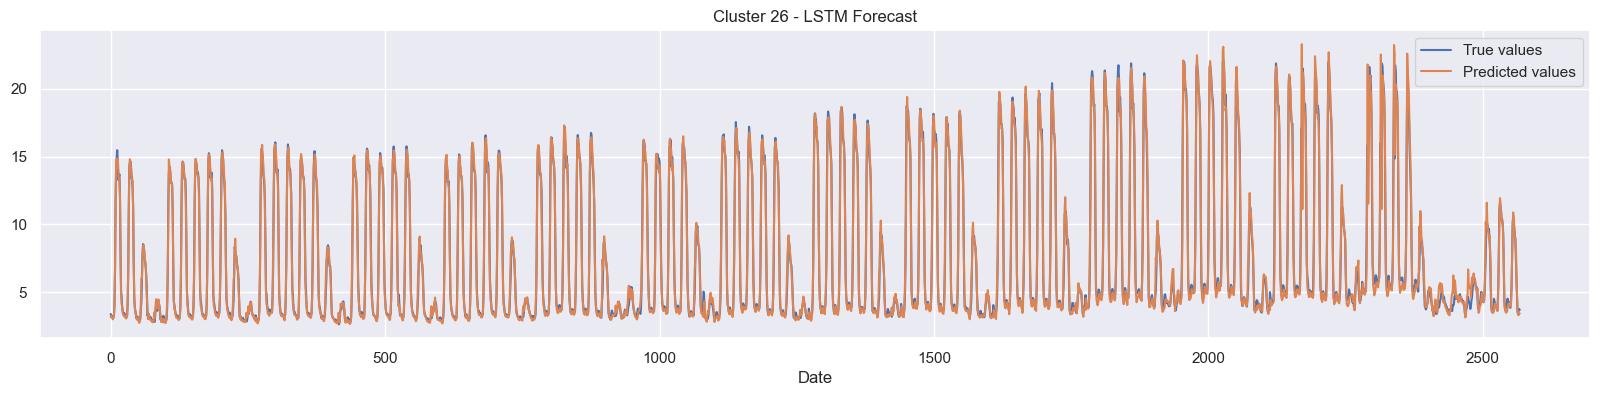

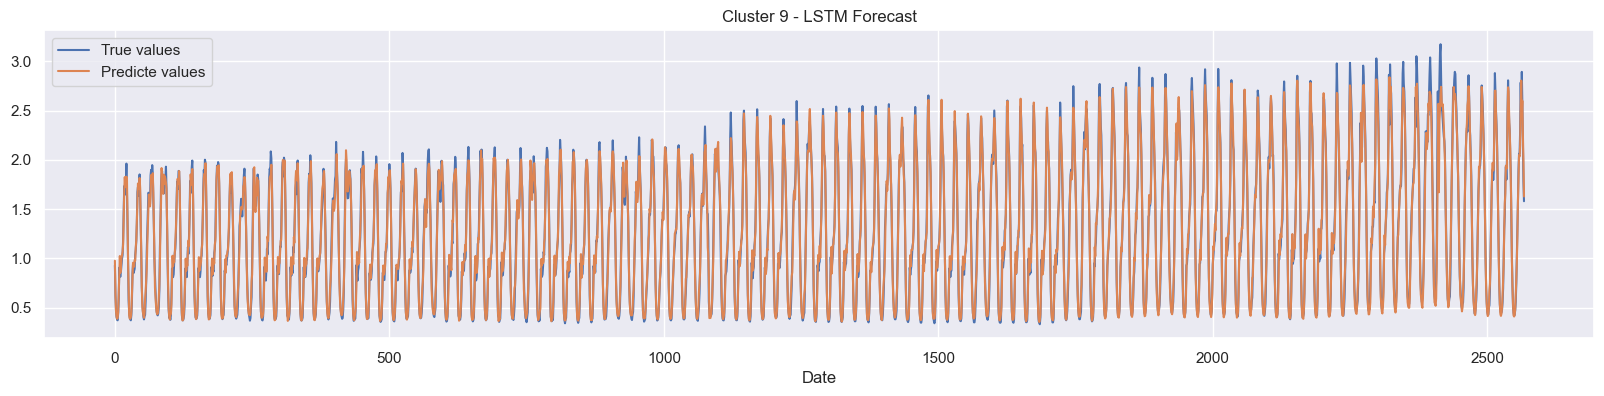

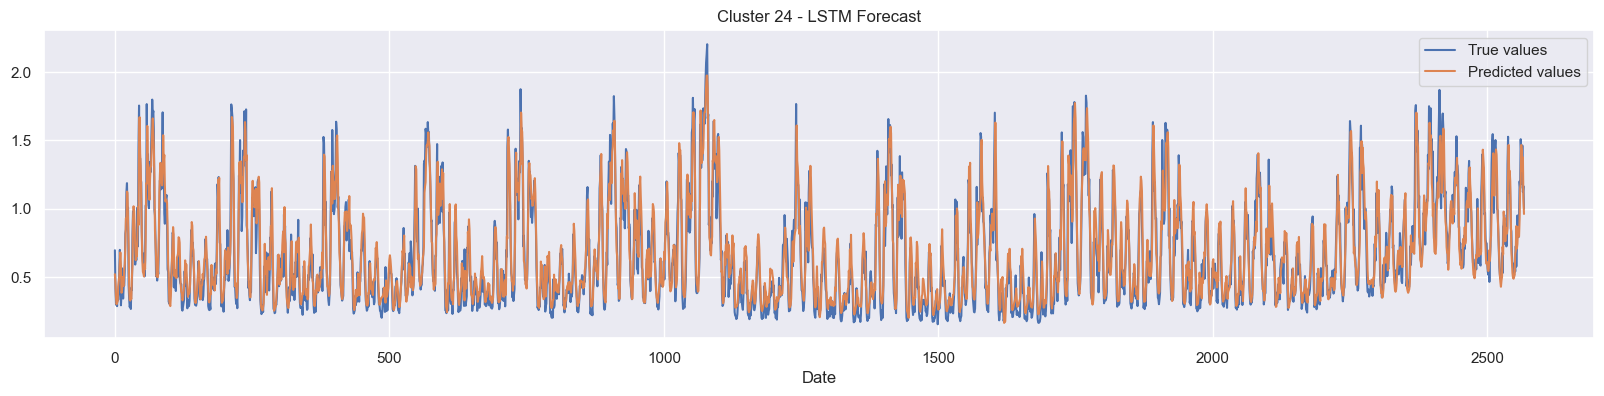

In [ ]:
plt.figure(figsize=(20,4))
plt.plot(y_test_rescaled_26, label="True values")
plt.plot(y_pred_lstm_26, label="Predicted values")
plt.legend()
plt.title("Cluster 26 - LSTM Forecast")
plt.xlabel("Date")
plt.xlim;

plt.figure(figsize=(20,4))
plt.plot(y_test_rescaled_9, label="True values")
plt.plot(y_pred_lstm_9, label="Predicted values")
plt.legend()
plt.title("Cluster 9 - LSTM Forecast")
plt.xlabel("Date")
plt.xlim;

plt.figure(figsize=(20,4))
plt.plot(y_test_rescaled_24, label="True values")
plt.plot(y_pred_lstm_24, label="Predicted values")
plt.legend()
plt.title("Cluster 24 - LSTM Forecast")
plt.xlabel("Date")
plt.xlim;

In [ ]:
lstm_results = metrics_results_func(y_test_rescaled_26, [y_pred_lstm_26], models = ['LSTM'])
lstm_results.rename(columns={'LSTM': 'LSTM_26'}, inplace=True)
lstm_results['LSTM_9'] = metrics_results_func(y_test_rescaled_9, [y_pred_lstm_9], models = ['LSTM'])['LSTM']
lstm_results['LSTM_24'] = metrics_results_func(y_test_rescaled_24, [y_pred_lstm_24], models = ['LSTM'])['LSTM']
lstm_results

,Metric,LSTM_26,LSTM_9,LSTM_24
0,RMSE,0.7210,0.0943,0.1534
1,MAE,0.3799,0.0667,0.1140
2,MAPE,0.0574,0.0608,0.1978


We graphically observe that the predicted values, in all three cases, are very close to the actual ones, and that in this case the weekly seasonality is also captured very well.  
As for the predictions on the test set, for clusters 26 and 9 the model has an average error of about 6%, while for cluster 24 it makes a larger error, of about 19%.

## Optimization and comparison

We optimize some hyperparameters (units, optimizer, batch_size) of the LSTM models for the three series.  
We will use RandomizedSearch.

In [ ]:
#defining the model and the RandomizedSearch for LSTM

def build_model_lstm(units=32, optimizer="adam"):
    model = Sequential([
        Input(shape=(window_size, 1)),
        LSTM(units, activation="tanh"),
        Dense(1)
    ])
    model.compile(optimizer=optimizer, loss="mse")
    return model


regressor = KerasRegressor(model=build_model_lstm, verbose=2)

param_grid_lstm = {
    "model__units": [16, 32],
    "model__optimizer": ["adam", "rmsprop", "sgd"],
    "fit__batch_size": [16, 32],
}

tscv = TimeSeriesSplit(n_splits=5)

search_lstm = RandomizedSearchCV(
    regressor,
    param_distributions=param_grid_lstm,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_iter=6,
    verbose=2
)

### Cluster 26

We perform the search using 20 epochs to reduce the time required

In [ ]:
search_lstm.fit(X_train_26, y_train_26, epochs=20)
print('best parameters', search_lstm.best_params_)
print('best score (RMSE):', -search_lstm.best_score_)
best_units26 = search_lstm.best_params_['model__units']
best_optimizer26 = search_lstm.best_params_['model__optimizer']
best_batchsize26 = search_lstm.best_params_['fit__batch_size']

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Epoch 1/20
54/54 - 1s - 19ms/step - loss: 0.0423
Epoch 2/20
54/54 - 0s - 5ms/step - loss: 0.0153
Epoch 3/20
54/54 - 0s - 4ms/step - loss: 0.0091
Epoch 4/20
54/54 - 0s - 4ms/step - loss: 0.0079
Epoch 5/20
54/54 - 0s - 4ms/step - loss: 0.0069
Epoch 6/20
54/54 - 0s - 4ms/step - loss: 0.0063
Epoch 7/20
54/54 - 0s - 4ms/step - loss: 0.0059
Epoch 8/20
54/54 - 0s - 4ms/step - loss: 0.0055
Epoch 9/20
54/54 - 0s - 4ms/step - loss: 0.0052
Epoch 10/20
54/54 - 0s - 4ms/step - loss: 0.0050
Epoch 11/20
54/54 - 0s - 4ms/step - loss: 0.0047
Epoch 12/20
54/54 - 0s - 4ms/step - loss: 0.0044
Epoch 13/20
54/54 - 0s - 4ms/step - loss: 0.0042
Epoch 14/20
54/54 - 0s - 4ms/step - loss: 0.0039
Epoch 15/20
54/54 - 0s - 4ms/step - loss: 0.0037
Epoch 16/20
54/54 - 0s - 4ms/step - loss: 0.0033
Epoch 17/20
54/54 - 0s - 4ms/step - loss: 0.0030
Epoch 18/20
54/54 - 0s - 4ms/step - loss: 0.0027
Epoch 19/20
54/54 - 0s - 4ms/step - loss: 0.0025
Epoch 20/20
54/54

We use the hyperparameters found to train the entire cluster 26 train set and make predictions. We use a number of epochs equal to 50.

In [ ]:
lstm26 = Sequential([
    Input(shape=(window_size, 1)),
    LSTM(best_units26, activation="tanh"),
    Dense(1)
])

lstm26.compile(optimizer=best_optimizer26, loss="mse")
lstm26.fit(X_train_26, y_train_26, epochs=50, batch_size=best_batchsize26)

y_pred_lstm_26 = lstm26.predict(X_test_26)
y_pred_lstm_26 = scaler_26.inverse_transform(y_pred_lstm_26)
y_test_rescaled_26 = scaler_26.inverse_transform(y_test_26)
y_train_rescaled_26 = scaler_26.inverse_transform(y_train_26)


Epoch 1/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0134
Epoch 2/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0049
Epoch 3/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0030
Epoch 4/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0020
Epoch 5/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0017
Epoch 6/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0015
Epoch 7/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0014
Epoch 8/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0013
Epoch 9/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0012
Epoch 10/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0012
Epoch 11/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0011
Epoch 12/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.0011
Epoch 13/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0010
Epoch 14/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 9.6595e-04
Epoch 15/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

### Cluster 9

In [ ]:
search_lstm.fit(X_train_9, y_train_9, epochs=20)
print('best prameters', search_lstm.best_params_)
print('best score (RMSE):', -search_lstm.best_score_)
best_units9 = search_lstm.best_params_['model__units']
best_optimizer9 = search_lstm.best_params_['model__optimizer']
best_batchsize9 = search_lstm.best_params_['fit__batch_size']

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Epoch 1/20
54/54 - 1s - 10ms/step - loss: 0.0395
Epoch 2/20
54/54 - 0s - 4ms/step - loss: 0.0278
Epoch 3/20
54/54 - 0s - 5ms/step - loss: 0.0272
Epoch 4/20
54/54 - 0s - 4ms/step - loss: 0.0266
Epoch 5/20
54/54 - 0s - 4ms/step - loss: 0.0261
Epoch 6/20
54/54 - 0s - 4ms/step - loss: 0.0255
Epoch 7/20
54/54 - 0s - 4ms/step - loss: 0.0250
Epoch 8/20
54/54 - 0s - 4ms/step - loss: 0.0246
Epoch 9/20
54/54 - 0s - 4ms/step - loss: 0.0241
Epoch 10/20
54/54 - 0s - 4ms/step - loss: 0.0236
Epoch 11/20
54/54 - 0s - 4ms/step - loss: 0.0232
Epoch 12/20
54/54 - 0s - 4ms/step - loss: 0.0228
Epoch 13/20
54/54 - 0s - 4ms/step - loss: 0.0224
Epoch 14/20
54/54 - 0s - 4ms/step - loss: 0.0220
Epoch 15/20
54/54 - 0s - 4ms/step - loss: 0.0216
Epoch 16/20
54/54 - 0s - 4ms/step - loss: 0.0212
Epoch 17/20
54/54 - 0s - 4ms/step - loss: 0.0209
Epoch 18/20
54/54 - 0s - 4ms/step - loss: 0.0205
Epoch 19/20
54/54 - 0s - 4ms/step - loss: 0.0202
Epoch 20/20
54/54

Here too we retrain the entire train set with the obtained hyperparameters

In [ ]:
lstm9 = Sequential([
    Input(shape=(window_size, 1)),
    LSTM(best_units9, activation="tanh"),
    Dense(1)
])

lstm9.compile(optimizer=best_optimizer9, loss="mse")
lstm9.fit(X_train_9, y_train_9, epochs=50, batch_size=best_batchsize9)

y_pred_lstm_9 = lstm9.predict(X_test_9)
y_pred_lstm_9 = scaler_9.inverse_transform(y_pred_lstm_9)
y_test_rescaled_9 = scaler_9.inverse_transform(y_test_9)
y_train_rescaled_9 = scaler_9.inverse_transform(y_train_9)

Epoch 1/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0079
Epoch 2/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0031
Epoch 3/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0026
Epoch 4/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0023
Epoch 5/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0020
Epoch 6/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0018
Epoch 7/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0017
Epoch 8/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0016
Epoch 9/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0015
Epoch 10/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0015
Epoch 11/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0014
Epoch 12/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0014
Epoch 13/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0014
Epoch 14/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0013
Epoch 15/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - lo

### Cluster 24

In [ ]:
search_lstm.fit(X_train_24, y_train_24, epochs=20)
print('best prameters', search_lstm.best_params_)
print('best score (RMSE):', -search_lstm.best_score_)
best_units24 = search_lstm.best_params_['model__units']
best_optimizer24 = search_lstm.best_params_['model__optimizer']
best_batchsize24 = search_lstm.best_params_['fit__batch_size']

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Epoch 1/20
107/107 - 1s - 7ms/step - loss: 0.0241
Epoch 2/20
107/107 - 0s - 3ms/step - loss: 0.0194
Epoch 3/20
107/107 - 0s - 3ms/step - loss: 0.0186
Epoch 4/20
107/107 - 0s - 3ms/step - loss: 0.0179
Epoch 5/20
107/107 - 0s - 3ms/step - loss: 0.0173
Epoch 6/20
107/107 - 0s - 3ms/step - loss: 0.0168
Epoch 7/20
107/107 - 0s - 3ms/step - loss: 0.0164
Epoch 8/20
107/107 - 0s - 3ms/step - loss: 0.0160
Epoch 9/20
107/107 - 0s - 3ms/step - loss: 0.0157
Epoch 10/20
107/107 - 0s - 3ms/step - loss: 0.0154
Epoch 11/20
107/107 - 0s - 3ms/step - loss: 0.0152
Epoch 12/20
107/107 - 0s - 3ms/step - loss: 0.0150
Epoch 13/20
107/107 - 0s - 3ms/step - loss: 0.0148
Epoch 14/20
107/107 - 0s - 3ms/step - loss: 0.0147
Epoch 15/20
107/107 - 0s - 3ms/step - loss: 0.0145
Epoch 16/20
107/107 - 0s - 3ms/step - loss: 0.0144
Epoch 17/20
107/107 - 0s - 3ms/step - loss: 0.0143
Epoch 18/20
107/107 - 0s - 3ms/step - loss: 0.0142
Epoch 19/20
107/107 - 0s - 3ms/

We train the entire train set with the obtained parameters.

In [ ]:
lstm24 = Sequential([
    Input(shape=(window_size, 1)),
    LSTM(best_units24, activation="tanh"),
    Dense(1)
])

lstm24.compile(optimizer=best_optimizer24, loss="mse")
lstm24.fit(X_train_24, y_train_24, epochs=50, batch_size=best_batchsize24)

y_pred_lstm_24 = lstm24.predict(X_test_24)
y_pred_lstm_24 = scaler_24.inverse_transform(y_pred_lstm_24)
y_test_rescaled_24 = scaler_24.inverse_transform(y_test_24)
y_train_rescaled_24 = scaler_24.inverse_transform(y_train_24)

Epoch 1/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0135
Epoch 2/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0061
Epoch 3/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.0055
Epoch 4/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0054
Epoch 5/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0053
Epoch 6/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0052
Epoch 7/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0050
Epoch 8/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0049
Epoch 9/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0049
Epoch 10/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0048
Epoch 11/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0047
Epoch 12/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0046
Epoch 13/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0046
Epoch 14/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0045
Epoch 15/50
641/641 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step -

### Comparison of results on the test set

We now compare, for each time series, the models built in order to choose the most suitable one. We also compute and print the predictions on the train set to check for the presence of overfitting.

In [ ]:
#test metrics
classic_models_results_26 = metrics_results_func(test_26, [ar_26_pred_mean, arima_26_pred_mean, sarima_26_pred_mean], models = ['AR(1)', 'ARIMA', 'SARIMA'])
lstm_model_result_26 = metrics_results_func(y_test_rescaled_26, [y_pred_lstm_26], models = ['LSTM'])

cluster26_results_test = pd.concat([classic_models_results_26, lstm_model_result_26['LSTM']], axis=1)

#train forecasting
ar_forecast_26_train = ar_result_26.get_forecast(steps=int(len(train_26)))
ar_26_pred_mean_train = ar_forecast_26_train.predicted_mean
arima_forecast_26_train = arima_result_26.get_forecast(steps=int(len(train_26)))
arima_26_pred_mean_train = arima_forecast_26_train.predicted_mean
sarima_forecast_26_train = sarima_result_26.get_forecast(steps=int(len(train_26)))
sarima_26_pred_mean_train = sarima_forecast_26_train.predicted_mean
y_pred_lstm_26_train = lstm26.predict(X_train_26)
y_pred_lstm_26_train = scaler_26.inverse_transform(y_pred_lstm_26_train)

#train metrics
classic_models_results_26_train = metrics_results_func(train_26, [ar_26_pred_mean_train, arima_26_pred_mean_train, sarima_26_pred_mean_train], models = ['AR(1)', 'ARIMA', 'SARIMA'])
lstm_model_result_26_train = metrics_results_func(y_train_rescaled_26, [y_pred_lstm_26_train], models = ['LSTM'])

cluster26_results_train = pd.concat([classic_models_results_26_train, lstm_model_result_26_train['LSTM']], axis=1)

321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
print('Train Metrics for Cluster 26:')
cluster26_results_train

Train Metrics for Cluster 26:


,Metric,AR(1),ARIMA,SARIMA,LSTM
0,RMSE,4.9218,4.9196,3.1020,0.4556
1,MAE,4.1868,4.1869,1.7764,0.3068
2,MAPE,0.7245,0.7252,0.3125,0.0484


In [ ]:
print('Test Metrics for Cluster 26:')
cluster26_results_test

Test Metrics for Cluster 26:


,Metric,AR(1),ARIMA,SARIMA,LSTM
0,RMSE,5.2588,5.2512,3.3408,0.7975
1,MAE,4.2708,4.2721,2.0812,0.3928
2,MAPE,0.6651,0.6677,0.3363,0.0549


Comparing the train and test set results, we can observe the absence of overfitting in all models, as the performances are very similar to each other.

From the test set results, we can observe that the SARIMA model already halves the prediction error; however, with the LSTM neural network the performance improves considerably, bringing the average percentage error down from about 33% to about 8%. Furthermore, as observed in the charts shown earlier, the SARIMA model was able to capture the daily seasonality well but not the weekly one, which we are instead able to do with the LSTM model.

In [ ]:
#test metrics
classic_models_results_9 = metrics_results_func(test_9, [ar_9_pred_mean, arima_9_pred_mean, sarima_9_pred_mean], models = ['AR(1)', 'ARIMA', 'SARIMA'])
lstm_model_result_9 = metrics_results_func(y_test_rescaled_9, [y_pred_lstm_9], models = ['LSTM'])

cluster9_results_test = pd.concat([classic_models_results_9, lstm_model_result_9['LSTM']], axis=1)

#train forecasting
ar_forecast_9_train = ar_result_9.get_forecast(steps=int(len(train_9)))
ar_9_pred_mean_train = ar_forecast_9_train.predicted_mean
arima_forecast_9_train = arima_result_9.get_forecast(steps=int(len(train_9)))
arima_9_pred_mean_train = arima_forecast_9_train.predicted_mean
sarima_forecast_9_train = sarima_result_9.get_forecast(steps=int(len(train_9)))
sarima_9_pred_mean_train = sarima_forecast_9_train.predicted_mean
y_pred_lstm_9_train = lstm9.predict(X_train_9)
y_pred_lstm_9_train = scaler_9.inverse_transform(y_pred_lstm_9_train)

#train metrics
classic_models_results_9_train = metrics_results_func(train_9, [ar_9_pred_mean_train, arima_9_pred_mean_train, sarima_9_pred_mean_train], models = ['AR(1)', 'ARIMA', 'SARIMA'])
lstm_model_result_9_train = metrics_results_func(y_train_rescaled_9, [y_pred_lstm_9_train], models = ['LSTM'])

cluster9_results_train = pd.concat([classic_models_results_9_train, lstm_model_result_9_train['LSTM']], axis=1)

321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
print('Train Metrics for Cluster 9:')
cluster9_results_train

Train Metrics for Cluster 9:


,Metric,AR(1),ARIMA,SARIMA,LSTM
0,RMSE,0.6047,0.6039,0.2812,0.0897
1,MAE,0.5069,0.5059,0.1756,0.0642
2,MAPE,0.6497,0.6479,0.1326,0.0612


In [ ]:
print('Test Metrics for Cluster 9:')
cluster9_results_test

Test Metrics for Cluster 9:


,Metric,AR(1),ARIMA,SARIMA,LSTM
0,RMSE,0.6991,0.6963,0.3657,0.0979
1,MAE,0.5887,0.5848,0.2369,0.0702
2,MAPE,0.6553,0.6486,0.1586,0.0639


Here too, overfitting results to be absent.

As for the performance on the test set, for cluster 9 as well we observe a marked improvement already with the SARIMA model, which has an average forecasting error of 15%. In this case, since the series does not have weekly seasonality, the error is much lower than for cluster 26. However, here too the LSTM model performs better, reducing the error to 8%, correctly capturing the higher values that SARIMA was unable to predict (see charts).

In [ ]:
#test metrics
classic_models_results_24 = metrics_results_func(test_24, [ar_24_pred_mean, arima_24_pred_mean, sarima_24_pred_mean], models = ['AR(1)', 'ARIMA', 'SARIMA'])
lstm_model_result_24 = metrics_results_func(y_test_rescaled_24, [y_pred_lstm_24], models = ['LSTM'])

cluster24_results_test = pd.concat([classic_models_results_24, lstm_model_result_24['LSTM']], axis=1)
cluster24_results_test

#train forecasting
ar_forecast_24_train = ar_result_24.get_forecast(steps=int(len(train_24)))
ar_24_pred_mean_train = ar_forecast_24_train.predicted_mean
arima_forecast_24_train = arima_result_24.get_forecast(steps=int(len(train_24)))
arima_24_pred_mean_train = arima_forecast_24_train.predicted_mean
sarima_forecast_24_train = sarima_result_24.get_forecast(steps=int(len(train_24)))
sarima_24_pred_mean_train = sarima_forecast_24_train.predicted_mean
y_pred_lstm_24_train = lstm24.predict(X_train_24)
y_pred_lstm_24_train = scaler_24.inverse_transform(y_pred_lstm_24_train)

#train metrics
classic_models_results_24_train = metrics_results_func(train_24, [ar_24_pred_mean_train, arima_24_pred_mean_train, sarima_24_pred_mean_train], models = ['AR(1)', 'ARIMA', 'SARIMA'])
lstm_model_result_24_train = metrics_results_func(y_train_rescaled_24, [y_pred_lstm_24_train], models = ['LSTM'])

cluster24_results_train = pd.concat([classic_models_results_24_train, lstm_model_result_24_train['LSTM']], axis=1)

321/321 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
print('Train Metrics for Cluster 24:')
cluster24_results_train

Train Metrics for Cluster 24:


,Metric,AR(1),ARIMA,SARIMA,LSTM
0,RMSE,0.3795,0.3795,0.3244,0.1459
1,MAE,0.3059,0.3059,0.2410,0.1059
2,MAPE,0.5352,0.5352,0.3704,0.1572


In [ ]:
print('Test Metrics for Cluster 24:')
cluster24_results_test

Test Metrics for Cluster 24:


,Metric,AR(1),ARIMA,SARIMA,LSTM
0,RMSE,0.3799,0.3799,0.3142,0.1496
1,MAE,0.3181,0.3181,0.2439,0.1073
2,MAPE,0.6870,0.6870,0.4532,0.1749


In the case of cluster 26, the errors on the test set are slightly higher than those on the train set, especially for the classical models when looking at the MAPE.

Also in terms of performance on the test set, also in this case the best model turns out to be the neural network, with a 17% error compared to 45% for the SARIMA model and 68% for the ARIMA models.

## Conclusions and recommendations

We built three models capable of forecasting the energy consumption of some building clusters in Ireland. In particular, despite the differences in behavior between the series, in this study the preferable model turns out to be, for all three, the one based on LSTM.  
Indeed, in the case of cluster 26, the classical models fail to adequately capture the series' double seasonality. As for cluster 9, on the other hand, the SARIMA model manages to capture the seasonal component, but graphically we observe that it is only able to correctly predict values in the short term, while over longer periods it tends to make greater errors on higher consumption values. This is not observed with the LSTM model, however, which considerably reduces the forecasting error (from 15% to 6%). Cluster 24, finally, has a very noisy series, and is in fact the one for which the models return the worst performances. However, the ACF and PACF analysis showed it to contain a seasonal element, which also emerged from the comparison of the ARIMA and SARIMA models. Despite this, the SARIMA model returns a MAPE of 45%, compared to 17% obtained with the LSTM model. In this case too, therefore, the neural network is preferred.  
In summary, LSTM proved to be the most suitable model for capturing the complexity of the three series analyzed, showing a superior ability to model the patterns involved and a higher degree of accuracy.  
This translates into more reliable and precise estimates of energy demand, useful for optimizing both the purchase of energy on the market and its distribution to buildings throughout the day.  
In the future, it may be useful to try to improve the models by introducing exogenous variables, such as outdoor temperature, which can influence a building's electricity consumption.